In [149]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


# Data Collection

In [150]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "5m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [151]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-06-10 02:05:00,69625.59,69691.99,69625.59,69670.01,63.50096
1,2024-06-10 02:10:00,69670.00,69697.66,69667.07,69697.66,88.00725
2,2024-06-10 02:15:00,69697.66,69779.21,69697.65,69754.34,98.51020
3,2024-06-10 02:20:00,69754.34,69774.92,69754.34,69774.91,38.74250
4,2024-06-10 02:25:00,69774.91,69790.00,69756.00,69772.00,66.65667


In [152]:
df.describe()

,timestamp,open,high,low,close,volume
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234


# Technical Indicators

### Momentum Indicators

#### <font color="#5283fe">Awesome Oscillator (AO)</font>
###### The Awesome Oscillator is an indicator used to measure market momentum. AO calculates the difference of a 34 Period and 5 Period Simple Moving Averages. The Simple Moving Averages that are used are not calculated using closing price but rather each bar’s midpoints. AO is generally used to affirm trends or to anticipate possible reversals.

In [153]:
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

df.describe()

,timestamp,open,high,low,close,volume,AO
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509


#### <font color="#5283fe">Kaufman’s Adaptive Moving Average (KAMA)</font>
###### Moving average designed to account for market noise or volatility. KAMA will closely follow prices when the price swings are relatively small and the noise is low. KAMA will adjust when the price swings widen and follow prices from a greater distance. This trend-following indicator can be used to identify the overall trend, time turning points and filter price movements.

In [154]:
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217


#### <font color="#5283fe">Percentage Price Oscillator (PPO)</font>
###### is a momentum oscillator that measures the difference between two moving averages as a percentage of the larger moving average.

In [155]:
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987


#### <font color="#5283fe">Percentage Volume Oscillator (PVO)</font>
###### is a momentum oscillator for volume. The PVO measures the difference between two volume-based moving averages as a percentage of the larger moving average.

In [156]:
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707


#### <font color="#5283fe">Rate of Change (ROC)</font>
###### The Rate-of-Change (ROC) indicator, which is also referred to as simply Momentum, is a pure momentum oscillator that measures the percent change in price from one period to the next. The ROC calculation compares the current price with the price “n” periods ago. The plot forms an oscillator that fluctuates above and below the zero line as the Rate-of-Change moves from positive to negative. As a momentum oscillator, ROC signals include centerline crossovers, divergences and overbought-oversold readings.

In [157]:
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000,105108.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094,0.006640
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191,-7.348482
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497,-0.219120
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216,0.006952
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383,0.236252
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168,7.057981
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707,0.539822


#### <font color="#5283fe">Relative Strength Index (RSI)</font>
###### Compares the magnitude of recent gains and losses over a specified time period to measure speed and change of price movements of a security. It is primarily used to attempt to identify overbought or oversold conditions in the trading of an asset.

In [158]:
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000,105108.000000,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094,0.006640,50.397285
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191,-7.348482,8.474526
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497,-0.219120,43.052057
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216,0.006952,50.586732
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383,0.236252,57.812414
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168,7.057981,93.901451
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707,0.539822,11.003777


#### <font color="#5283fe">Stochastic RSI</font>
###### The StochRSI oscillator was developed to take advantage of both momentum indicators in order to create a more sensitive indicator that is attuned to a specific security’s historical performance rather than a generalized analysis of price change.

In [159]:
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000,105108.000000,105107.000000,105094.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094,0.006640,50.397285,0.501370
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191,-7.348482,8.474526,0.000000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497,-0.219120,43.052057,0.164529
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216,0.006952,50.586732,0.502986
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383,0.236252,57.812414,0.838987
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168,7.057981,93.901451,1.000000
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707,0.539822,11.003777,0.357383


#### <font color="#5283fe">Stochastic Oscillator</font>
###### Developed in the late 1950s by George Lane. The stochastic oscillator presents the location of the closing price of a stock in relation to the high and low range of the price of a stock over a period of time, typically a 14-day period.

In [160]:
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000,105108.000000,105107.000000,105094.000000,105107.000000,105105.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094,0.006640,50.397285,0.501370,51.220879,51.221271
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191,-7.348482,8.474526,0.000000,0.000000,0.000000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497,-0.219120,43.052057,0.164529,25.174199,26.292019
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216,0.006952,50.586732,0.502986,51.815309,51.720735
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383,0.236252,57.812414,0.838987,77.529913,76.309744
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168,7.057981,93.901451,1.000000,100.000000,100.000000
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707,0.539822,11.003777,0.357383,29.808695,27.577247


#### <font color="#5283fe">True strength index (TSI)</font>
###### Shows both trend direction and overbought/oversold conditions.

In [161]:
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000,105108.000000,105107.000000,105094.000000,105107.000000,105105.000000,105083.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094,0.006640,50.397285,0.501370,51.220879,51.221271,0.808805
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497,-0.219120,43.052057,0.164529,25.174199,26.292019,-11.825066
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216,0.006952,50.586732,0.502986,51.815309,51.720735,1.046669
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383,0.236252,57.812414,0.838987,77.529913,76.309744,13.497170
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707,0.539822,11.003777,0.357383,29.808695,27.577247,18.533646


### Volume Indicators

#### <font color="#5283fe">Accumulation/Distribution Index (ADI)</font>
###### The accumulation distribution indicator (AD) or accumulation distribution line is a volume-based indicator used to determine the trend of a stock, using the relation between the stock’s price and volume flow.

In [162]:
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105095.000000,105087.000000,105087.000000,105108.000000,105107.000000,105094.000000,105107.000000,105105.000000,105083.000000,105120.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,-2.701387,-0.000061,-2.700094,0.006640,50.397285,0.501370,51.220879,51.221271,0.808805,77007.467555
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-58.109294,-24.660745,-54.221191,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083,-23517.947442
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-14.191996,-5.340823,-12.280497,-0.219120,43.052057,0.164529,25.174199,26.292019,-11.825066,980.039057
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,-4.668719,-1.079069,-3.720216,0.006952,50.586732,0.502986,51.815309,51.720735,1.046669,122656.742629
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,6.726463,3.943626,5.833383,0.236252,57.812414,0.838987,77.529913,76.309744,13.497170,135987.350584
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,84.770303,70.479989,55.021168,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186,157268.590524
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,16.533753,8.183054,13.771707,0.539822,11.003777,0.357383,29.808695,27.577247,18.533646,66824.220178


#### <font color="#5283fe">Chaikin Money Flow (CMF)</font>
###### It measures the amount of Money Flow Volume over a specific period..

In [163]:
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105087.000000,105087.000000,105108.000000,105107.000000,105094.000000,105107.000000,105105.000000,105083.000000,105120.000000,105101.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,-0.000061,-2.700094,0.006640,50.397285,0.501370,51.220879,51.221271,0.808805,77007.467555,0.011314
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-24.660745,-54.221191,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083,-23517.947442,-0.756104
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-5.340823,-12.280497,-0.219120,43.052057,0.164529,25.174199,26.292019,-11.825066,980.039057,-0.101595
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,-1.079069,-3.720216,0.006952,50.586732,0.502986,51.815309,51.720735,1.046669,122656.742629,0.010438
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,3.943626,5.833383,0.236252,57.812414,0.838987,77.529913,76.309744,13.497170,135987.350584,0.124006
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,70.479989,55.021168,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186,157268.590524,0.719828
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,8.183054,13.771707,0.539822,11.003777,0.357383,29.808695,27.577247,18.533646,66824.220178,0.166682


#### <font color="#5283fe">Ease of movement (EoM, EMV)</font>
###### It relate an asset’s price change to its volume and is particularly useful for assessing the strength of a trend.

In [164]:
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105108.000000,105107.000000,105094.000000,105107.000000,105105.000000,105083.000000,105120.000000,105101.000000,1.051190e+05,1.051060e+05
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.006640,50.397285,0.501370,51.220879,51.221271,0.808805,77007.467555,0.011314,1.254749e+08,1.256489e+08
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-0.219120,43.052057,0.164529,25.174199,26.292019,-11.825066,980.039057,-0.101595,-8.114142e+09,-2.476055e+09
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.006952,50.586732,0.502986,51.815309,51.720735,1.046669,122656.742629,0.010438,1.283987e+07,1.155659e+08
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.236252,57.812414,0.838987,77.529913,76.309744,13.497170,135987.350584,0.124006,8.199937e+09,2.747505e+09
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186,157268.590524,0.719828,3.661549e+11,6.058626e+10
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.539822,11.003777,0.357383,29.808695,27.577247,18.533646,66824.220178,0.166682,2.165935e+10,5.897721e+09


#### <font color="#5283fe">Force Index (FI)</font>
###### It illustrates how strong the actual buying or selling pressure is. High positive values mean there is a strong rising trend, and low values signify a strong downward trend.

In [165]:
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105107.000000,105094.000000,105107.000000,105105.000000,105083.000000,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,50.397285,0.501370,51.220879,51.221271,0.808805,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,8.474526,0.000000,0.000000,0.000000,-70.563083,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,43.052057,0.164529,25.174199,26.292019,-11.825066,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,50.586732,0.502986,51.815309,51.720735,1.046669,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,57.812414,0.838987,77.529913,76.309744,13.497170,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,93.901451,1.000000,100.000000,100.000000,74.403186,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,11.003777,0.357383,29.808695,27.577247,18.533646,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04


#### <font color="#5283fe">Money Flow Index (MFI)</font>
###### Uses both price and volume to measure buying and selling pressure. It is positive when the typical price rises (buying pressure) and negative when the typical price declines (selling pressure). A ratio of positive and negative money flow is then plugged into an RSI formula to create an oscillator that moves between zero and one hundred.

In [166]:
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105094.000000,105107.000000,105105.000000,105083.000000,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.501370,51.220879,51.221271,0.808805,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.000000,0.000000,0.000000,-70.563083,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,0.164529,25.174199,26.292019,-11.825066,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.502986,51.815309,51.720735,1.046669,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.838987,77.529913,76.309744,13.497170,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,1.000000,100.000000,100.000000,74.403186,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.357383,29.808695,27.577247,18.533646,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094


#### <font color="#5283fe">Negative Volume Index (NVI)</font>
###### 

In [167]:
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105107.000000,105105.000000,105083.000000,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000,105120.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,51.220879,51.221271,0.808805,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995,2558.677359
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.000000,0.000000,-70.563083,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,995.575196
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,25.174199,26.292019,-11.825066,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888,1799.658532
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,51.815309,51.720735,1.046669,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731,2344.206623
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,77.529913,76.309744,13.497170,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710,3653.673796
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,100.000000,100.000000,74.403186,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,4176.348258
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,29.808695,27.577247,18.533646,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094,991.910905


#### <font color="#5283fe">On-balance volume (OBV)</font>
###### It relates price and volume in the stock market. OBV is based on a cumulative total volume.

In [168]:
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105105.000000,105083.000000,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000,105120.000000,105120.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,51.221271,0.808805,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995,2558.677359,-30379.399306
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.000000,-70.563083,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,995.575196,-92390.494990
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,26.292019,-11.825066,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888,1799.658532,-50918.460977
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,51.720735,1.046669,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731,2344.206623,-29046.973463
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,76.309744,13.497170,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710,3653.673796,-2452.552525
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,100.000000,74.403186,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,4176.348258,26192.309745
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,27.577247,18.533646,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094,991.910905,29703.897260


#### <font color="#5283fe">Volume-price trend (VPT)</font>
###### Is based on a running cumulative volume that adds or substracts a multiple of the percentage change in share price trend and current volume, depending upon the investment’s upward or downward movements.

In [169]:
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105083.000000,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000,105120.000000,105120.000000,105119.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.808805,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995,2558.677359,-30379.399306,-377.787809
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-70.563083,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,995.575196,-92390.494990,-716.853402
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-11.825066,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888,1799.658532,-50918.460977,-516.550886
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,1.046669,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731,2344.206623,-29046.973463,-354.194560
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,13.497170,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710,3653.673796,-2452.552525,-297.737106
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,74.403186,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,4176.348258,26192.309745,19.235383
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,18.533646,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094,991.910905,29703.897260,130.498351


#### <font color="#5283fe">Volume Weighted Average Price (VWAP)</font>
###### VWAP equals the dollar value of all trading periods divided by the total trading volume for the current day. The calculation starts when trading opens and ends when it closes. Because it is good for the current trading day only, intraday periods and data are used in the calculation.

In [170]:
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000,105120.000000,105120.000000,105119.000000,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995,2558.677359,-30379.399306,-377.787809,81615.820745
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,995.575196,-92390.494990,-716.853402,50220.052577
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888,1799.658532,-50918.460977,-516.550886,64097.056404
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731,2344.206623,-29046.973463,-354.194560,84268.302665
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710,3653.673796,-2452.552525,-297.737106,96905.140725
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,4176.348258,26192.309745,19.235383,111739.423432
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094,991.910905,29703.897260,130.498351,17159.221508


### Volatility Indicators

#### <font color="#5283fe">Average True Range (ATR)</font>
###### The indicator provide an indication of the degree of price volatility. Strong moves, in either direction, are often accompanied by large ranges, or large True Ranges.

In [171]:
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000,105120.000000,105120.000000,105119.000000,105107.000000,105120.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995,2558.677359,-30379.399306,-377.787809,81615.820745,153.102307
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,995.575196,-92390.494990,-716.853402,50220.052577,0.000000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888,1799.658532,-50918.460977,-516.550886,64097.056404,86.163981
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731,2344.206623,-29046.973463,-354.194560,84268.302665,127.714366
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710,3653.673796,-2452.552525,-297.737106,96905.140725,189.799969
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,4176.348258,26192.309745,19.235383,111739.423432,1476.575039
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094,991.910905,29703.897260,130.498351,17159.221508,101.121037


#### <font color="#5283fe">Bollinger Bands</font>
###### envelopes plotted at a standard deviation level above and below a simple moving average of the price.

In [172]:
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105119.000000,105107.000000,105120.000000,105101.000000,105120.000000,105101.000000,105120.000000,105101.000000,105101.000000,105101.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,-377.787809,81615.820745,153.102307,81971.195617,0.056707,81268.025951,0.058695,81619.610784,0.506380,0.867081
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-716.853402,50220.052577,0.000000,51535.110799,0.000000,48686.167072,0.000000,50473.117500,-0.556350,0.062412
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-516.550886,64097.056404,86.163981,64311.548637,0.000000,63858.759068,0.000000,64096.769500,0.243685,0.430239
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,-354.194560,84268.302665,127.714366,84547.502465,0.000000,83986.202585,0.000000,84271.478000,0.517179,0.652676
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,-297.737106,96905.140725,189.799969,97254.759762,0.000000,96532.791582,0.000000,96911.210000,0.766957,1.034131
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,19.235383,111739.423432,1476.575039,112284.305074,1.000000,111392.260452,1.000000,111682.710500,1.560557,10.833275
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,130.498351,17159.221508,101.121037,17224.044950,0.231282,17097.840323,0.235054,17158.291185,0.328703,0.741637


#### <font color="#5283fe">Donchian Channel</font>
###### Donchian channels are technical indicators primarily used to identify breakout points and retracements, which are key for traders looking to capture significant trends.

In [173]:
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105120.000000,105101.000000,105101.000000,105101.000000,105101.000000,105101.000000,105101.000000,105101.000000,105101.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,81268.025951,0.058695,81619.610784,0.506380,0.867081,81991.282714,81227.382324,81609.332519,0.515277,0.943820
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,48686.167072,0.000000,50473.117500,-0.556350,0.062412,51640.490000,49000.000000,50591.660000,0.000000,0.073439
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,63858.759068,0.000000,64096.769500,0.243685,0.430239,64318.820000,63816.050000,64089.970000,0.261493,0.499910
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,83986.202585,0.000000,84271.478000,0.517179,0.652676,84581.600000,83960.000000,84258.415000,0.525504,0.741434
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,96532.791582,0.000000,96911.210000,0.766957,1.034131,97268.650000,96510.090000,96893.500000,0.770473,1.147400
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,111392.260452,1.000000,111682.710500,1.560557,10.833275,111980.000000,111379.220000,111679.610000,1.000000,10.857242
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,17097.840323,0.235054,17158.291185,0.328703,0.741637,17223.648554,17093.506519,17156.033776,0.292847,0.727864


#### <font color="#5283fe">Keltner Channels</font>
###### Keltner Channels are a trend following indicator used to identify reversals with channel breakouts and channel direction. Channels can also be used to identify overbought and oversold levels when the trend is flat.

In [174]:
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105101.000000,105101.000000,105120.000000,105120.000000,105120.000000,105120.000000,105101.000000,105120.000000,105101.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,81609.332519,0.515277,0.943820,81769.910914,0.279956,81463.689758,0.262766,81618.949963,0.521901,0.377720
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,50591.660000,0.000000,0.073439,51042.720000,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,64089.970000,0.261493,0.499910,64172.887750,0.000000,64018.610042,0.000000,64096.152833,-0.032705,0.215593
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,84258.415000,0.525504,0.741434,84385.893167,0.000000,84153.393833,0.000000,84271.737833,0.535678,0.311935
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,96893.500000,0.770473,1.147400,97057.197083,1.000000,96741.700458,1.000000,96908.502500,1.074127,0.467167
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,111679.610000,1.000000,10.857242,111872.738167,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,17156.033776,0.292847,0.727864,17184.750936,0.448980,17130.164784,0.440139,17157.954983,0.860570,0.252290


#### <font color="#5283fe">Ulcer Index</font>
######  is a technical indicator used in finance to measure downside risk and volatility, specifically the amount of price drawdown or retracement over a period.

In [175]:
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105101.000000,105120.000000,105120.000000,105120.000000,105120.000000,105101.000000,105120.000000,105101.000000,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.515277,0.943820,81769.910914,0.279956,81463.689758,0.262766,81618.949963,0.521901,0.377720,0.346055
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.000000,0.073439,51042.720000,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757,0.004325
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,0.261493,0.499910,64172.887750,0.000000,64018.610042,0.000000,64096.152833,-0.032705,0.215593,0.144064
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.525504,0.741434,84385.893167,0.000000,84153.393833,0.000000,84271.737833,0.535678,0.311935,0.248753
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.770473,1.147400,97057.197083,1.000000,96741.700458,1.000000,96908.502500,1.074127,0.467167,0.423976
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,1.000000,10.857242,111872.738167,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968,4.974310
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.292847,0.727864,17184.750936,0.448980,17130.164784,0.440139,17157.954983,0.860570,0.252290,0.336780


### Trend Indicators

#### <font color="#5283fe">Average Directional Movement Index (ADX)</font>
######  The Plus Directional Indicator (+DI) and Minus Directional Indicator (-DI) are derived from smoothed averages of these differences, and measure trend direction over time. These two indicators are often referred to collectively as the Directional Movement Indicator (DMI).

In [176]:
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105120.000000,105120.000000,105120.000000,105101.000000,105120.000000,105101.000000,105107.000000,105120.000000,105120.000000,105120.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.279956,81463.689758,0.262766,81618.949963,0.521901,0.377720,0.346055,24.499190,23.514390,23.470439
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757,0.004325,0.000000,0.000000,0.000000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,0.000000,64018.610042,0.000000,64096.152833,-0.032705,0.215593,0.144064,16.924552,17.814779,17.910553
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.000000,84153.393833,0.000000,84271.737833,0.535678,0.311935,0.248753,22.356119,22.938128,22.873801
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,1.000000,96741.700458,1.000000,96908.502500,1.074127,0.467167,0.423976,30.037827,28.506060,28.302914
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968,4.974310,75.862033,78.562443,75.661542
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.448980,17130.164784,0.440139,17157.954983,0.860570,0.252290,0.336780,10.072850,8.118245,7.876858


#### <font color="#5283fe">Aroon Indicator</font>
###### Identify when trends are likely to change direction.

In [177]:
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105120.000000,105101.000000,105107.000000,105120.000000,105120.000000,105120.000000,105095.000000,105095.000000,105095.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,81618.949963,0.521901,0.377720,0.346055,24.499190,23.514390,23.470439,47.872192,46.295104,1.577087
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,50480.640500,-4.195300,0.019757,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,64096.152833,-0.032705,0.215593,0.144064,16.924552,17.814779,17.910553,12.000000,12.000000,-56.000000
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,84271.737833,0.535678,0.311935,0.248753,22.356119,22.938128,22.873801,48.000000,44.000000,12.000000
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,96908.502500,1.074127,0.467167,0.423976,30.037827,28.506060,28.302914,84.000000,80.000000,56.000000
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,111680.646667,6.461352,3.335968,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,17157.954983,0.860570,0.252290,0.336780,10.072850,8.118245,7.876858,35.564630,35.531098,61.565854


#### <font color="#5283fe">Commodity Channel Index (CCI)</font>
###### CCI measures the difference between a security’s price change and its average price change. High positive readings indicate that prices are well above their average, which is a show of strength. Low negative readings indicate that prices are well below their average, which is a show of weakness.

In [178]:
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105120.000000,105101.000000,105107.000000,105120.000000,105120.000000,105120.000000,105095.000000,105095.000000,105095.000000,105101.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.521901,0.377720,0.346055,24.499190,23.514390,23.470439,47.872192,46.295104,1.577087,2.164161
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-4.195300,0.019757,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-0.032705,0.215593,0.144064,16.924552,17.814779,17.910553,12.000000,12.000000,-56.000000,-83.296651
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.535678,0.311935,0.248753,22.356119,22.938128,22.873801,48.000000,44.000000,12.000000,6.034718
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,1.074127,0.467167,0.423976,30.037827,28.506060,28.302914,84.000000,80.000000,56.000000,86.485414
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,6.461352,3.335968,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.860570,0.252290,0.336780,10.072850,8.118245,7.876858,35.564630,35.531098,61.565854,110.974852


#### <font color="#5283fe">Detrended Price Oscillator (DPO)</font>
###### Is an indicator designed to remove trend from price and make it easier to identify cycles.

In [179]:
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105107.000000,105120.000000,105120.000000,105120.000000,105095.000000,105095.000000,105095.000000,105101.000000,105101.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.377720,0.346055,24.499190,23.514390,23.470439,47.872192,46.295104,1.577087,2.164161,-0.570583
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.019757,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,0.215593,0.144064,16.924552,17.814779,17.910553,12.000000,12.000000,-56.000000,-83.296651,-73.687000
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.311935,0.248753,22.356119,22.938128,22.873801,48.000000,44.000000,12.000000,6.034718,0.407000
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.467167,0.423976,30.037827,28.506060,28.302914,84.000000,80.000000,56.000000,86.485414,74.702500
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,3.335968,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.252290,0.336780,10.072850,8.118245,7.876858,35.564630,35.531098,61.565854,110.974852,173.288778


#### <font color="#5283fe">EMA - Exponential Moving Average</font>
###### .

In [180]:
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105107.000000,105120.000000,105120.000000,105120.000000,105095.000000,105095.000000,105095.000000,105101.000000,105101.000000,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.346055,24.499190,23.514390,23.470439,47.872192,46.295104,1.577087,2.164161,-0.570583,81620.075104
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.004325,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000,50246.268523
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,0.144064,16.924552,17.814779,17.910553,12.000000,12.000000,-56.000000,-83.296651,-73.687000,64102.146471
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.248753,22.356119,22.938128,22.873801,48.000000,44.000000,12.000000,6.034718,0.407000,84275.572975
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.423976,30.037827,28.506060,28.302914,84.000000,80.000000,56.000000,86.485414,74.702500,96906.947621
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,4.974310,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500,111708.867629
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,0.336780,10.072850,8.118245,7.876858,35.564630,35.531098,61.565854,110.974852,173.288778,17158.511145


#### <font color="#5283fe">KST Oscillator (KST Signal)</font>
###### It is useful to identify major stock market cycle junctures because its formula is weighed to be more greatly influenced by the longer and more dominant time spans, in order to better reflect the primary swings of stock market cycle.

In [181]:
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105120.000000,105095.000000,105095.000000,105095.000000,105101.000000,105101.000000,105107.000000,105106.000000,105106.000000,105106.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,23.470439,47.872192,46.295104,1.577087,2.164161,-0.570583,81620.075104,0.103146,0.098165,0.004981
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000,50246.268523,-138.400039,-138.400039,-18.246464
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,17.910553,12.000000,12.000000,-56.000000,-83.296651,-73.687000,64102.146471,-2.337011,-2.296092,-0.852323
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,22.873801,48.000000,44.000000,12.000000,6.034718,0.407000,84275.572975,0.178679,0.182574,-0.018116
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,28.302914,84.000000,80.000000,56.000000,86.485414,74.702500,96906.947621,2.697524,2.645670,0.845976
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500,111708.867629,64.420254,62.790486,26.668654
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,7.876858,35.564630,35.531098,61.565854,110.974852,173.288778,17158.511145,6.095113,6.021623,1.896236


#### <font color="#5283fe">Moving Average Convergence Divergence (MACD)</font>
###### Is a trend-following momentum indicator that shows the relationship between two moving averages of prices.

In [182]:
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105095.000000,105101.000000,105101.000000,105107.000000,105106.000000,105106.000000,105106.000000,105095.000000,105087.000000,105087.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,1.577087,2.164161,-0.570583,81620.075104,0.103146,0.098165,0.004981,2.680852,2.683888,-0.000991
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-100.000000,-558.885709,-3034.398000,50246.268523,-138.400039,-138.400039,-18.246464,-1204.342743,-956.947865,-495.832950
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-56.000000,-83.296651,-73.687000,64102.146471,-2.337011,-2.296092,-0.852323,-54.164110,-50.990622,-18.435709
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,12.000000,6.034718,0.407000,84275.572975,0.178679,0.182574,-0.018116,4.198700,4.182822,-0.328734
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,56.000000,86.485414,74.702500,96906.947621,2.697524,2.645670,0.845976,63.222302,60.197607,18.602340
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,100.000000,543.127093,2156.694500,111708.867629,64.420254,62.790486,26.668654,1713.440432,1543.369576,632.062555
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,61.565854,110.974852,173.288778,17158.511145,6.095113,6.021623,1.896236,143.894211,135.598413,43.081845


#### <font color="#5283fe">Mass Index (MI)</font>
###### It uses the high-low range to identify trend reversals based on range expansions. It identifies range bulges that can foreshadow a reversal of the current trend.

In [183]:
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105101.000000,105107.000000,105106.000000,105106.000000,105106.000000,105095.000000,105087.000000,105087.000000,105080.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,2.164161,-0.570583,81620.075104,0.103146,0.098165,0.004981,2.680852,2.683888,-0.000991,24.931213
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-558.885709,-3034.398000,50246.268523,-138.400039,-138.400039,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-83.296651,-73.687000,64102.146471,-2.337011,-2.296092,-0.852323,-54.164110,-50.990622,-18.435709,23.812672
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,6.034718,0.407000,84275.572975,0.178679,0.182574,-0.018116,4.198700,4.182822,-0.328734,24.754307
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,86.485414,74.702500,96906.947621,2.697524,2.645670,0.845976,63.222302,60.197607,18.602340,25.880331
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,543.127093,2156.694500,111708.867629,64.420254,62.790486,26.668654,1713.440432,1543.369576,632.062555,32.583755
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,110.974852,173.288778,17158.511145,6.095113,6.021623,1.896236,143.894211,135.598413,43.081845,1.629271


#### <font color="#5283fe">SMA - Simple Moving Average</font>
###### 

In [184]:
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105101.000000,105107.000000,105106.000000,105106.000000,105106.000000,105095.000000,105087.000000,105087.000000,105080.000000,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,-0.570583,81620.075104,0.103146,0.098165,0.004981,2.680852,2.683888,-0.000991,24.931213,81620.078540
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-3034.398000,50246.268523,-138.400039,-138.400039,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-73.687000,64102.146471,-2.337011,-2.296092,-0.852323,-54.164110,-50.990622,-18.435709,23.812672,64100.136786
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.407000,84275.572975,0.178679,0.182574,-0.018116,4.198700,4.182822,-0.328734,24.754307,84271.616429
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,74.702500,96906.947621,2.697524,2.645670,0.845976,63.222302,60.197607,18.602340,25.880331,96910.074643
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,2156.694500,111708.867629,64.420254,62.790486,26.668654,1713.440432,1543.369576,632.062555,32.583755,111728.397143
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,173.288778,17158.511145,6.095113,6.021623,1.896236,143.894211,135.598413,43.081845,1.629271,17159.053537


#### <font color="#5283fe">Vortex Indicator (VI)</font>
###### It consists of two oscillators that capture positive and negative trend movement. A bullish signal triggers when the positive trend indicator crosses above the negative trend indicator or a key level.

In [185]:
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105106.000000,105106.000000,105095.000000,105087.000000,105087.000000,105080.000000,105107.000000,105106.000000,105106.000000,105106.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.098165,0.004981,2.680852,2.683888,-0.000991,24.931213,81620.078540,1.006241,0.995350,0.010891
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-138.400039,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857,0.231102,0.154251,-1.314552
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-2.296092,-0.852323,-54.164110,-50.990622,-18.435709,23.812672,64100.136786,0.883959,0.876984,-0.232506
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,0.182574,-0.018116,4.198700,4.182822,-0.328734,24.754307,84271.616429,1.010455,0.999941,0.011112
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,2.645670,0.845976,63.222302,60.197607,18.602340,25.880331,96910.074643,1.130133,1.118129,0.251480
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,62.790486,26.668654,1713.440432,1543.369576,632.062555,32.583755,111728.397143,1.964244,1.642198,1.479364
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,6.021623,1.896236,143.894211,135.598413,43.081845,1.629271,17159.053537,0.173741,0.170784,0.339866


#### <font color="#5283fe">WMA - Weighted Moving Average</font>
###### .

In [186]:
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105120,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105087.000000,105111.000000,105095.000000,1.050870e+05,...,105106.000000,105095.000000,105087.000000,105087.000000,105080.000000,105107.000000,105106.000000,105106.000000,105106.000000,105107.000000
mean,2024-12-09 14:02:30.000000256,81620.704744,81696.653215,81543.536241,81621.085609,98.562376,5.558595,81617.088272,0.002770,-4.537467e-07,...,0.004981,2.680852,2.683888,-0.000991,24.931213,81620.078540,1.006241,0.995350,0.010891,81620.904594
min,2024-06-10 02:05:00,49351.260000,49966.620000,49000.000000,49338.490000,1.755100,-3567.873088,50687.935750,-1.916957,-6.220705e-01,...,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857,0.231102,0.154251,-1.314552,50115.079429
25%,2024-09-09 08:03:45,64098.460000,64136.660000,64050.000000,64098.450000,31.920427,-139.624176,64113.936616,-0.068626,-2.330175e-02,...,-0.852323,-54.164110,-50.990622,-18.435709,23.812672,64100.136786,0.883959,0.876984,-0.232506,64100.863905
50%,2024-12-09 14:02:30,84282.980000,84343.865000,84222.975000,84283.010000,58.316560,9.841559,84268.813244,0.005445,-4.740871e-04,...,-0.018116,4.198700,4.182822,-0.328734,24.754307,84271.616429,1.010455,0.999941,0.011112,84275.004190
75%,2025-03-10 20:01:15,96899.840000,96975.315000,96816.812500,96899.992500,111.772458,157.667250,96901.232677,0.079476,2.329099e-02,...,0.845976,63.222302,60.197607,18.602340,25.880331,96910.074643,1.130133,1.118129,0.251480,96908.351381
max,2025-06-10 02:00:00,111924.070000,111980.000000,111812.420000,111924.080000,5471.439430,4895.497941,111640.246496,1.823188,6.782993e-01,...,26.668654,1713.440432,1543.369576,632.062555,32.583755,111728.397143,1.964244,1.642198,1.479364,111730.558000
std,NaN,17160.620187,17173.938221,17146.777674,17160.799384,138.995234,364.452509,17160.572217,0.176089,5.259583e-02,...,1.896236,143.894211,135.598413,43.081845,1.629271,17159.053537,0.173741,0.170784,0.339866,17159.639781


### Constants

In [187]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Data Structure

In [188]:
df.head(10)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-06-10 02:05:00,69625.59,69691.99,69625.59,69670.01,63.50096,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-06-10 02:10:00,69670.00,69697.66,69667.07,69697.66,88.00725,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-06-10 02:15:00,69697.66,69779.21,69697.65,69754.34,98.51020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-06-10 02:20:00,69754.34,69774.92,69754.34,69774.91,38.74250,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-06-10 02:25:00,69774.91,69790.00,69756.00,69772.00,66.65667,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-06-10 02:30:00,69772.01,69790.00,69772.00,69780.01,43.07497,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-06-10 02:35:00,69780.01,69801.34,69766.09,69766.09,69.51958,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-06-10 02:40:00,69766.10,69792.00,69747.94,69772.93,97.36396,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-06-10 02:45:00,69772.93,69772.93,69730.00,69730.25,35.95376,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-06-10 02:50:00,69730.24,69751.16,69721.42,69721.42,25.15743,NaN,69721.42,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105120 entries, 0 to 105119
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            105120 non-null  datetime64[ns]
 1   open                 105120 non-null  float64       
 2   high                 105120 non-null  float64       
 3   low                  105120 non-null  float64       
 4   close                105120 non-null  float64       
 5   volume               105120 non-null  float64       
 6   AO                   105087 non-null  float64       
 7   KAMA                 105111 non-null  float64       
 8   PPO                  105095 non-null  float64       
 9   PPO_HIST             105087 non-null  float64       
 10  PPO_SIGNAL           105087 non-null  float64       
 11  PVO                  105095 non-null  float64       
 12  PVO_HIST             105087 non-null  float64       
 13  PVO_SIGNAL    

### Histogram by section

##### <font color="yellow"> OCHLV </font>

In [190]:
df[OCHLV].describe()

,open,close,high,low,volume
count,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
mean,81620.704744,81621.085609,81696.653215,81543.536241,98.562376
std,17160.620187,17160.799384,17173.938221,17146.777674,138.995234
min,49351.260000,49338.490000,49966.620000,49000.000000,1.755100
25%,64098.460000,64098.450000,64136.660000,64050.000000,31.920427
50%,84282.980000,84283.010000,84343.865000,84222.975000,58.316560
75%,96899.840000,96899.992500,96975.315000,96816.812500,111.772458
max,111924.070000,111924.080000,111980.000000,111812.420000,5471.439430


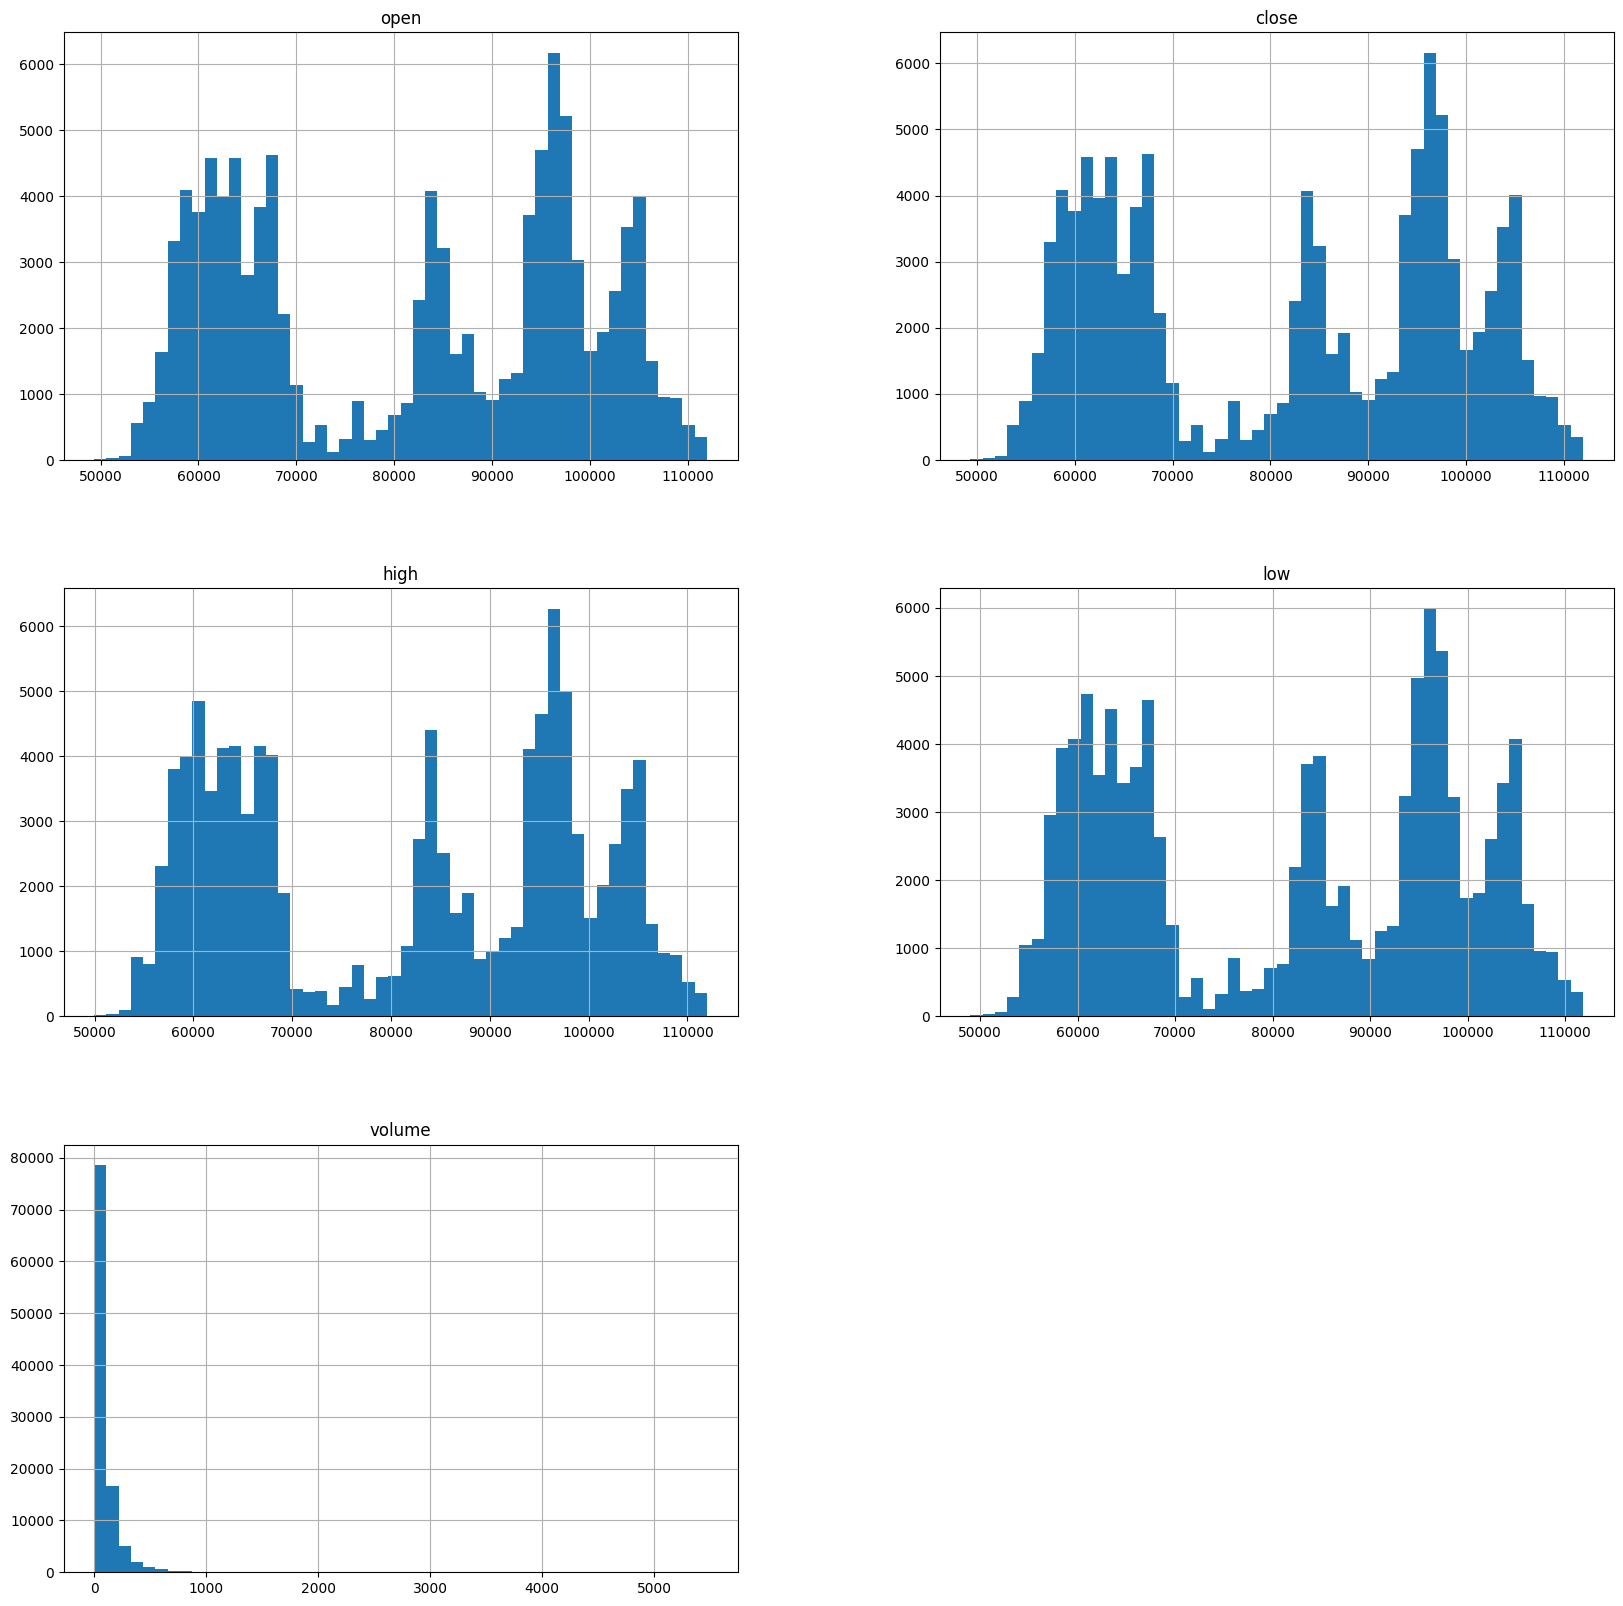

In [191]:
df[OCHLV].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font> I can say that Open, Close, High and Low share the same pattern. The exception is Volume. </font>

#### <font color="yellow"> MOMENTUM. </font>

In [192]:
df[MOMENTUM].describe()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,105087.000000,105111.000000,105095.000000,1.050870e+05,105087.000000,105095.000000,105087.000000,105087.000000,105108.000000,105107.000000,105094.000000,105107.000000,105105.000000,105083.000000
mean,5.558595,81617.088272,0.002770,-4.537467e-07,0.002774,-2.701387,-0.000061,-2.700094,0.006640,50.397285,0.501370,51.220879,51.221271,0.808805
std,364.452509,17160.572217,0.176089,5.259583e-02,0.165987,16.533753,8.183054,13.771707,0.539822,11.003777,0.357383,29.808695,27.577247,18.533646
min,-3567.873088,50687.935750,-1.916957,-6.220705e-01,-1.608772,-58.109294,-24.660745,-54.221191,-7.348482,8.474526,0.000000,0.000000,0.000000,-70.563083
25%,-139.624176,64113.936616,-0.068626,-2.330175e-02,-0.064867,-14.191996,-5.340823,-12.280497,-0.219120,43.052057,0.164529,25.174199,26.292019,-11.825066
50%,9.841559,84268.813244,0.005445,-4.740871e-04,0.005378,-4.668719,-1.079069,-3.720216,0.006952,50.586732,0.502986,51.815309,51.720735,1.046669
75%,157.667250,96901.232677,0.079476,2.329099e-02,0.075405,6.726463,3.943626,5.833383,0.236252,57.812414,0.838987,77.529913,76.309744,13.497170
max,4895.497941,111640.246496,1.823188,6.782993e-01,1.701378,84.770303,70.479989,55.021168,7.057981,93.901451,1.000000,100.000000,100.000000,74.403186


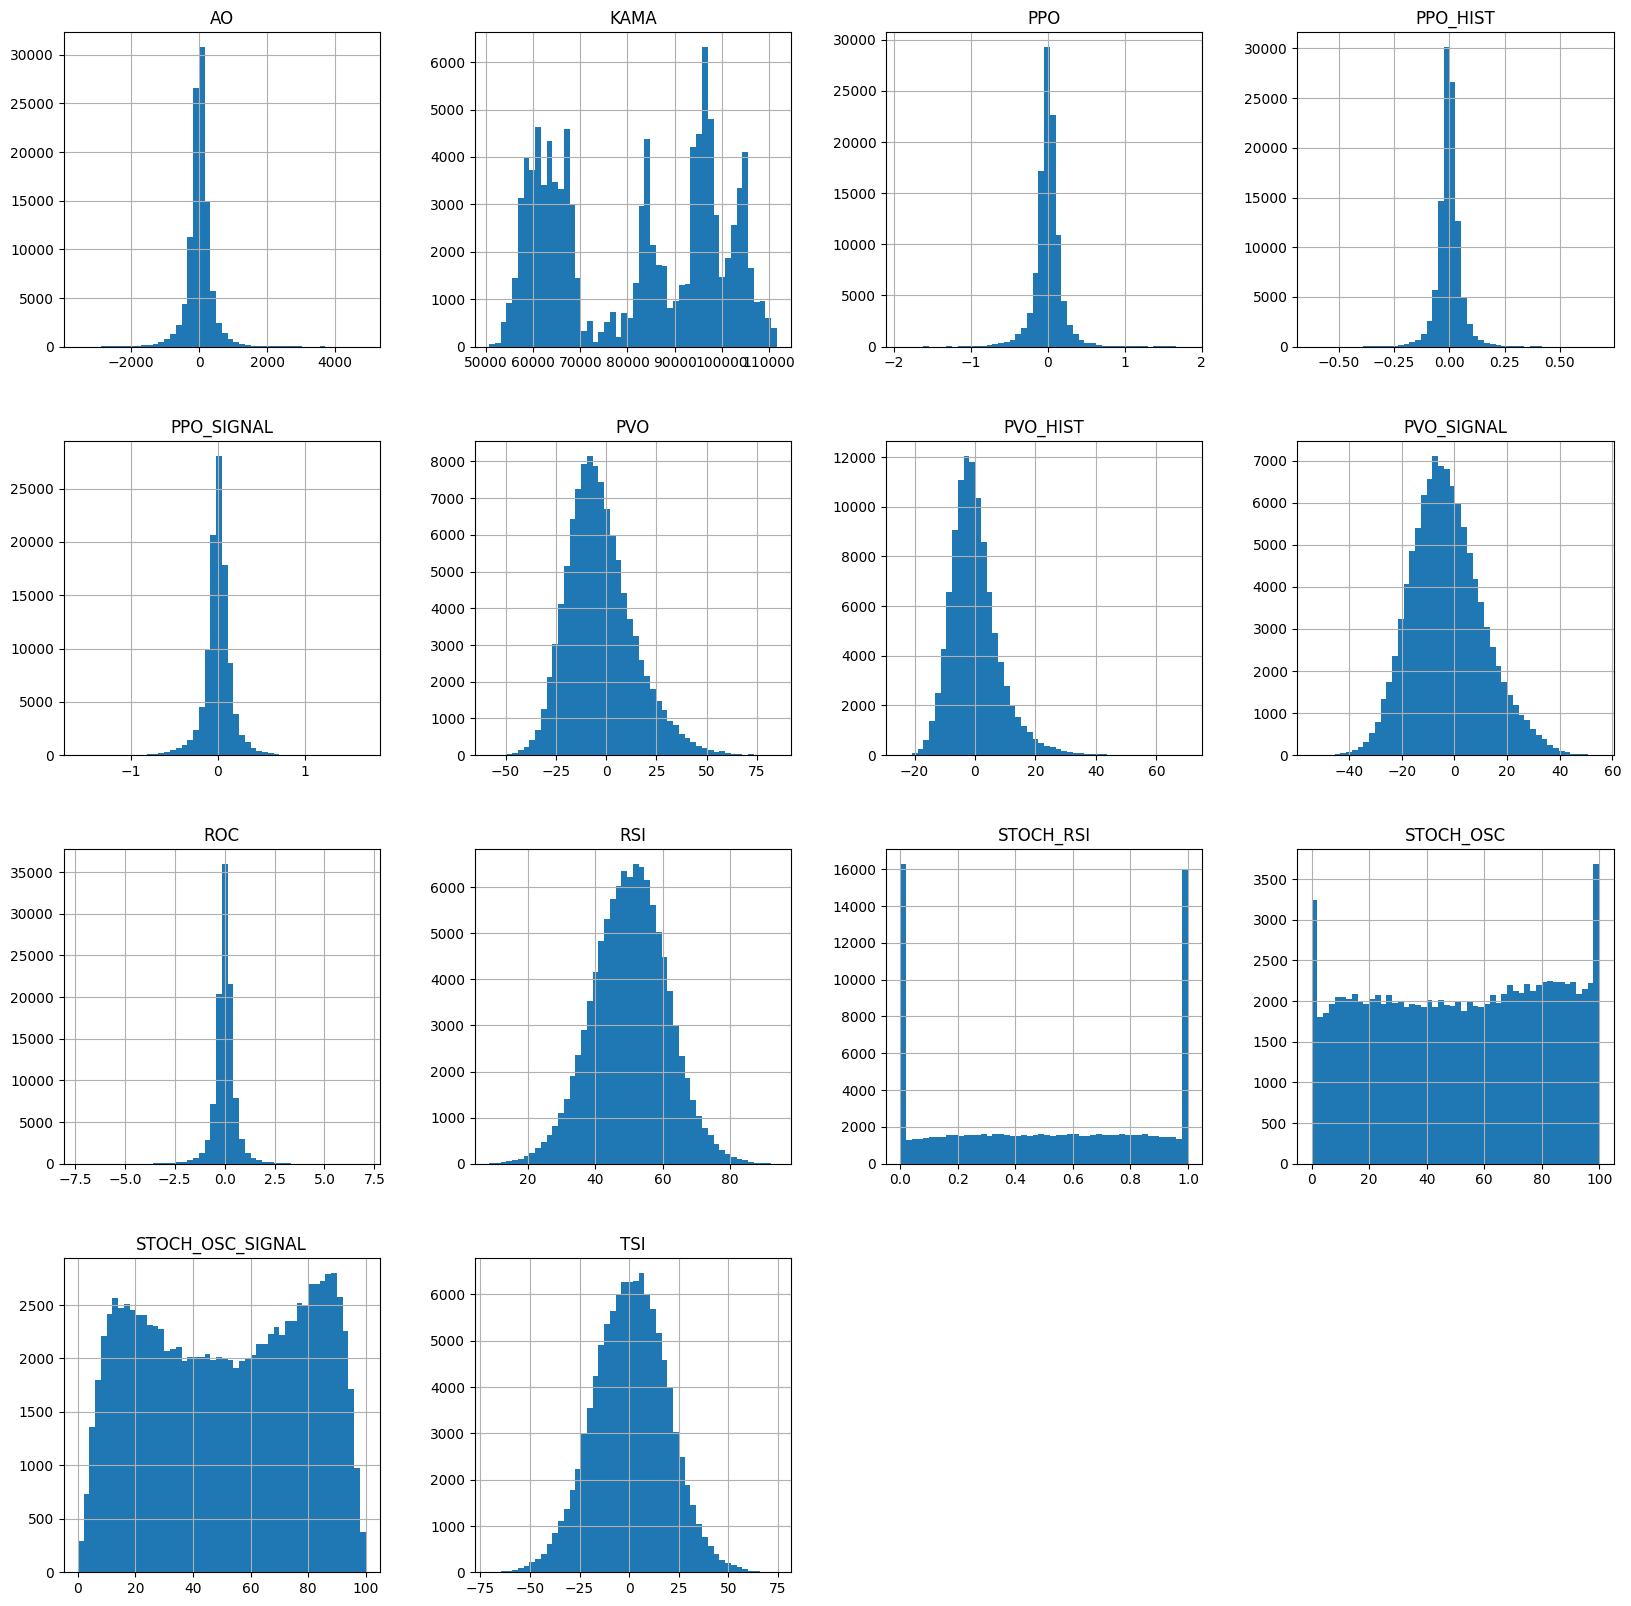

In [193]:
df[MOMENTUM].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow"> MOMENTUM. </font>
<font color="#5283fe">BELL</font>
<ol>
  <li>AO</li>
  <li>PPO</li>
  <li>PPO Hist</li>
  <li>PPO Signal</li>
  <li>PVO</li>
  <li>PVO Hist</li>
  <li>PVO Signal</li>
  <li>ROC</li>
  <li>RSI</li>
  <li>TSI</li>
</ol>
<p>Is the same pattern for these indicators, so there are posibilities that we can discard some of this indicators.</p>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>KAMA</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated.</p>

<font color="#5283fe">Other</font>
<ol>
  <li>STOCH RSI</li>
  <li>STOCH OSC</li>
  <li>STOCH OSC SIGNAL</li>
</ol>
<p>Need to understand how this works.</p>

#### <font color="yellow"> Volumen </font>

In [194]:
df[VOLUME].describe()

,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,105120.000000,105101.000000,1.051190e+05,1.051060e+05,1.051070e+05,105107.000000,105120.000000,105120.000000,105119.000000,105107.000000
mean,77007.467555,0.011314,1.254749e+08,1.256489e+08,-1.414806e+02,49.973995,2558.677359,-30379.399306,-377.787809,81615.820745
std,66824.220178,0.166682,2.165935e+10,5.897721e+09,3.127370e+04,18.046094,991.910905,29703.897260,130.498351,17159.221508
min,-23517.947442,-0.756104,-5.326924e+11,-5.958277e+10,-3.136686e+06,0.000000,995.575196,-92390.494990,-716.853402,50220.052577
25%,980.039057,-0.101595,-8.114142e+09,-2.476055e+09,-1.207944e+03,36.717888,1799.658532,-50918.460977,-516.550886,64097.056404
50%,122656.742629,0.010438,1.283987e+07,1.155659e+08,2.788493e+01,49.922731,2344.206623,-29046.973463,-354.194560,84268.302665
75%,135987.350584,0.124006,8.199937e+09,2.747505e+09,1.291205e+03,63.348710,3653.673796,-2452.552525,-297.737106,96905.140725
max,157268.590524,0.719828,3.661549e+11,6.058626e+10,1.250264e+06,100.000000,4176.348258,26192.309745,19.235383,111739.423432


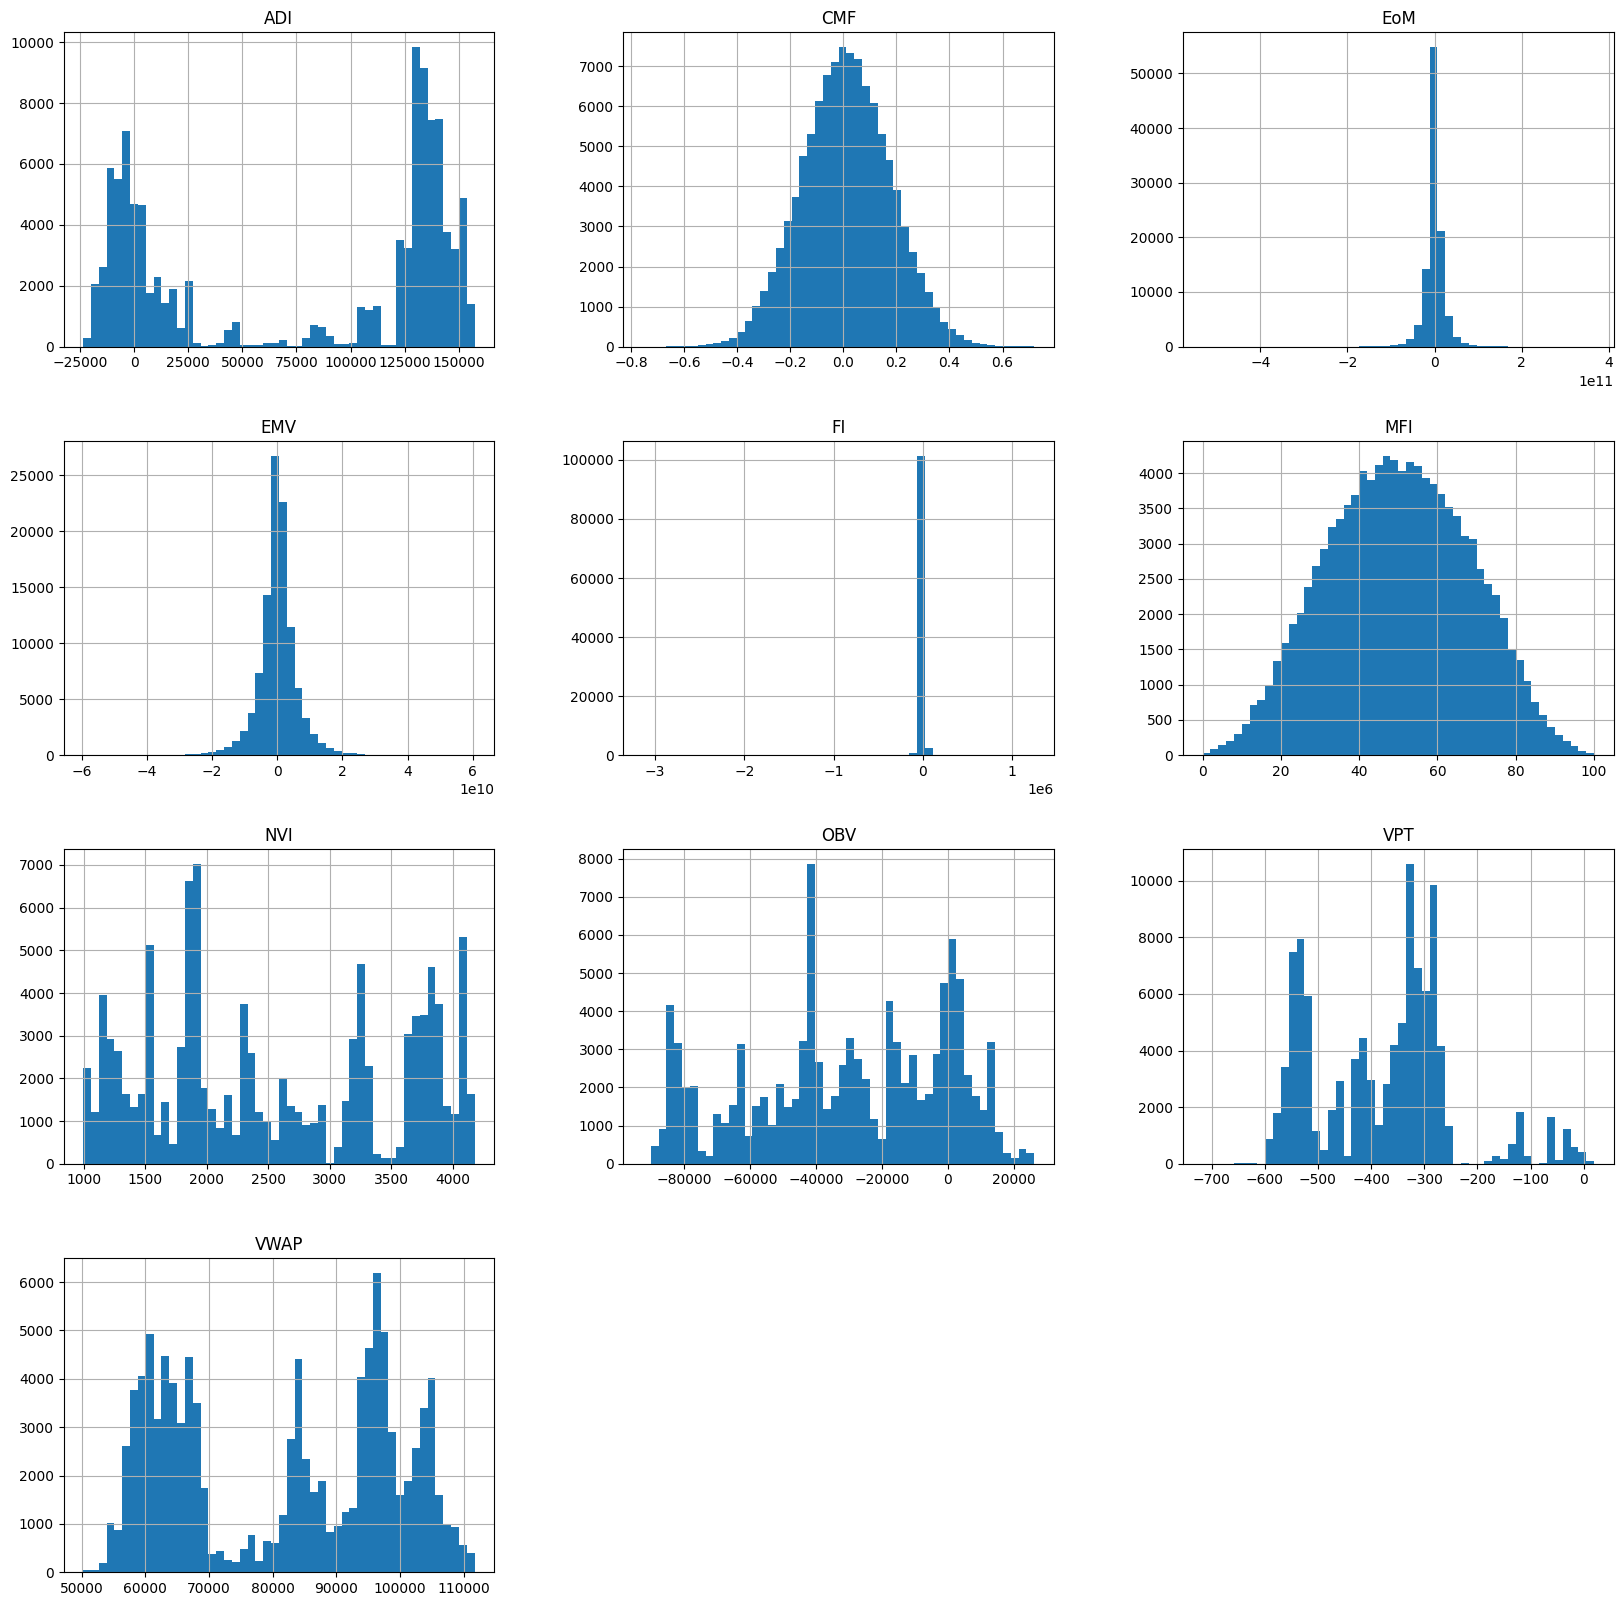

In [195]:
df[VOLUME].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow"> VOLUME </font>
<font color="#5283fe">BELL</font>
<ol>
  <li>CMF</li>
  <li>MFI</li>
  <li>EoM</li>
  <li>EMV</li>
  <li>FI</li>
</ol>
<p>Is the same pattern for these indicators, need the check the scale.</p>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>VWAP</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated.</p>

<font color="#5283fe">Unique Patterns</font>
<ol>
  <li>ADI</li>
  <li>NVI</li>
  <li>OBV</li>
  <li>VPT</li>
</ol>
<p>Need to understand how this works.</p>

####  <font color="yellow">VOLATILITY </font>

In [196]:
df[VOLATILITY].describe()

,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,105120.000000,105101.000000,105120.000000,105101.000000,105120.000000,105101.000000,105101.000000,105101.000000,105101.000000,105101.000000,...,105101.000000,105101.000000,105120.000000,105120.000000,105120.000000,105120.000000,105101.000000,105120.000000,105101.000000,105107.000000
mean,153.102307,81971.195617,0.056707,81268.025951,0.058695,81619.610784,0.506380,0.867081,81991.282714,81227.382324,...,0.515277,0.943820,81769.910914,0.279956,81463.689758,0.262766,81618.949963,0.521901,0.377720,0.346055
std,101.121037,17224.044950,0.231282,17097.840323,0.235054,17158.291185,0.328703,0.741637,17223.648554,17093.506519,...,0.292847,0.727864,17184.750936,0.448980,17130.164784,0.440139,17157.954983,0.860570,0.252290,0.336780
min,0.000000,51535.110799,0.000000,48686.167072,0.000000,50473.117500,-0.556350,0.062412,51640.490000,49000.000000,...,0.000000,0.073439,51042.720000,0.000000,49775.918000,0.000000,50480.640500,-4.195300,0.019757,0.004325
25%,86.163981,64311.548637,0.000000,63858.759068,0.000000,64096.769500,0.243685,0.430239,64318.820000,63816.050000,...,0.261493,0.499910,64172.887750,0.000000,64018.610042,0.000000,64096.152833,-0.032705,0.215593,0.144064
50%,127.714366,84547.502465,0.000000,83986.202585,0.000000,84271.478000,0.517179,0.652676,84581.600000,83960.000000,...,0.525504,0.741434,84385.893167,0.000000,84153.393833,0.000000,84271.737833,0.535678,0.311935,0.248753
75%,189.799969,97254.759762,0.000000,96532.791582,0.000000,96911.210000,0.766957,1.034131,97268.650000,96510.090000,...,0.770473,1.147400,97057.197083,1.000000,96741.700458,1.000000,96908.502500,1.074127,0.467167,0.423976
max,1476.575039,112284.305074,1.000000,111392.260452,1.000000,111682.710500,1.560557,10.833275,111980.000000,111379.220000,...,1.000000,10.857242,111872.738167,1.000000,111488.555167,1.000000,111680.646667,6.461352,3.335968,4.974310


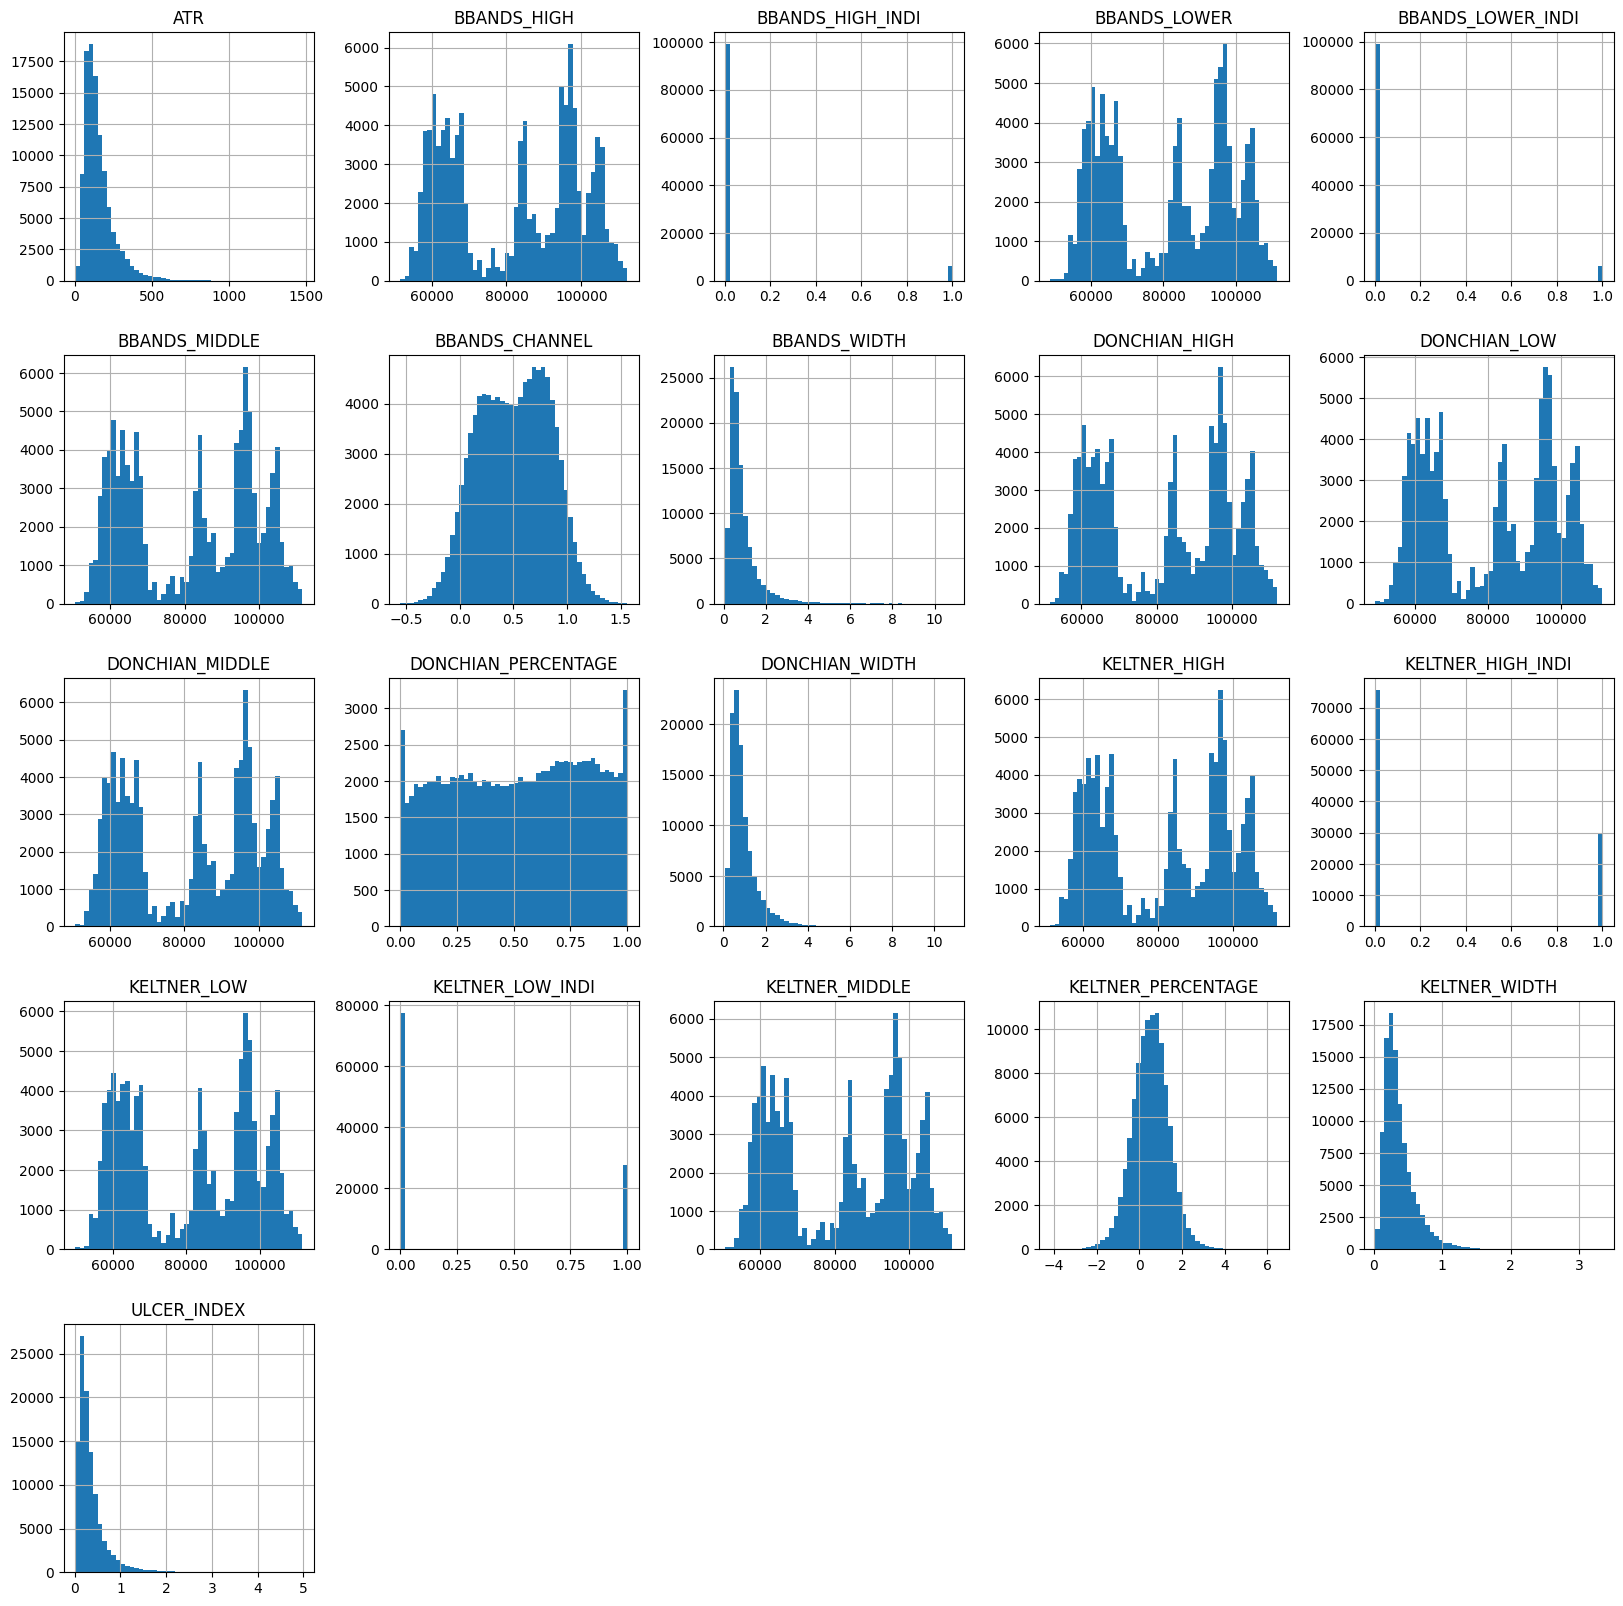

In [197]:
df[VOLATILITY].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow">VOLATILITY </font>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>BBANDS HIGH</li>
  <li>BBANDS LOWER</li>
  <li>BBANDS MIDDLE</li>
  <li>KELTNER HIGH</li>
  <li>KELTNER LOWER</li>
  <li>KELTNER MIDDLE</li>
  <li>DONCHIAN HIGH</li>
  <li>DONCHIAN LOWER</li>
  <li>DONCHIAN MIDDLE</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated. Also if they have the same porpouse probably im gonna need to chose one between Bolinger Bands, Keltner or Donchian.</p>

<font color="#5283fe">Indicators (0 or 1)</font>
<ol>
  <li>BBANDS HIGH INDI</li>
  <li>BBANDS LOWER INDI</li>
  <li>DONCHIAN HIGH INDI</li>
  <li>DONCHIAN LOWER INDI</li>
</ol>
<p>The same as before, need to choose one.</p>

<font color="#5283fe">Width</font>
<ol>
  <li>BBANDS Width</li>
  <li>DONCHIAN Width</li>
  <li>KELTNER Width</li>
  <li>ULCER INDEX</li>
  <li>ATR</li>
</ol>
<p>Need to understand how this works.</p>

#### <font color="yellow">TREND </font>

In [198]:
df[TREND].describe()

,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,105120.000000,105120.000000,105120.000000,105095.000000,105095.000000,105095.000000,105101.000000,105101.000000,105107.000000,105106.000000,...,105106.000000,105095.000000,105087.000000,105087.000000,105080.000000,105107.000000,105106.000000,105106.000000,105106.000000,105107.000000
mean,24.499190,23.514390,23.470439,47.872192,46.295104,1.577087,2.164161,-0.570583,81620.075104,0.103146,...,0.004981,2.680852,2.683888,-0.000991,24.931213,81620.078540,1.006241,0.995350,0.010891,81620.904594
std,10.072850,8.118245,7.876858,35.564630,35.531098,61.565854,110.974852,173.288778,17158.511145,6.095113,...,1.896236,143.894211,135.598413,43.081845,1.629271,17159.053537,0.173741,0.170784,0.339866,17159.639781
min,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-558.885709,-3034.398000,50246.268523,-138.400039,...,-18.246464,-1204.342743,-956.947865,-495.832950,18.721716,50201.332857,0.231102,0.154251,-1.314552,50115.079429
25%,16.924552,17.814779,17.910553,12.000000,12.000000,-56.000000,-83.296651,-73.687000,64102.146471,-2.337011,...,-0.852323,-54.164110,-50.990622,-18.435709,23.812672,64100.136786,0.883959,0.876984,-0.232506,64100.863905
50%,22.356119,22.938128,22.873801,48.000000,44.000000,12.000000,6.034718,0.407000,84275.572975,0.178679,...,-0.018116,4.198700,4.182822,-0.328734,24.754307,84271.616429,1.010455,0.999941,0.011112,84275.004190
75%,30.037827,28.506060,28.302914,84.000000,80.000000,56.000000,86.485414,74.702500,96906.947621,2.697524,...,0.845976,63.222302,60.197607,18.602340,25.880331,96910.074643,1.130133,1.118129,0.251480,96908.351381
max,75.862033,78.562443,75.661542,100.000000,100.000000,100.000000,543.127093,2156.694500,111708.867629,64.420254,...,26.668654,1713.440432,1543.369576,632.062555,32.583755,111728.397143,1.964244,1.642198,1.479364,111730.558000


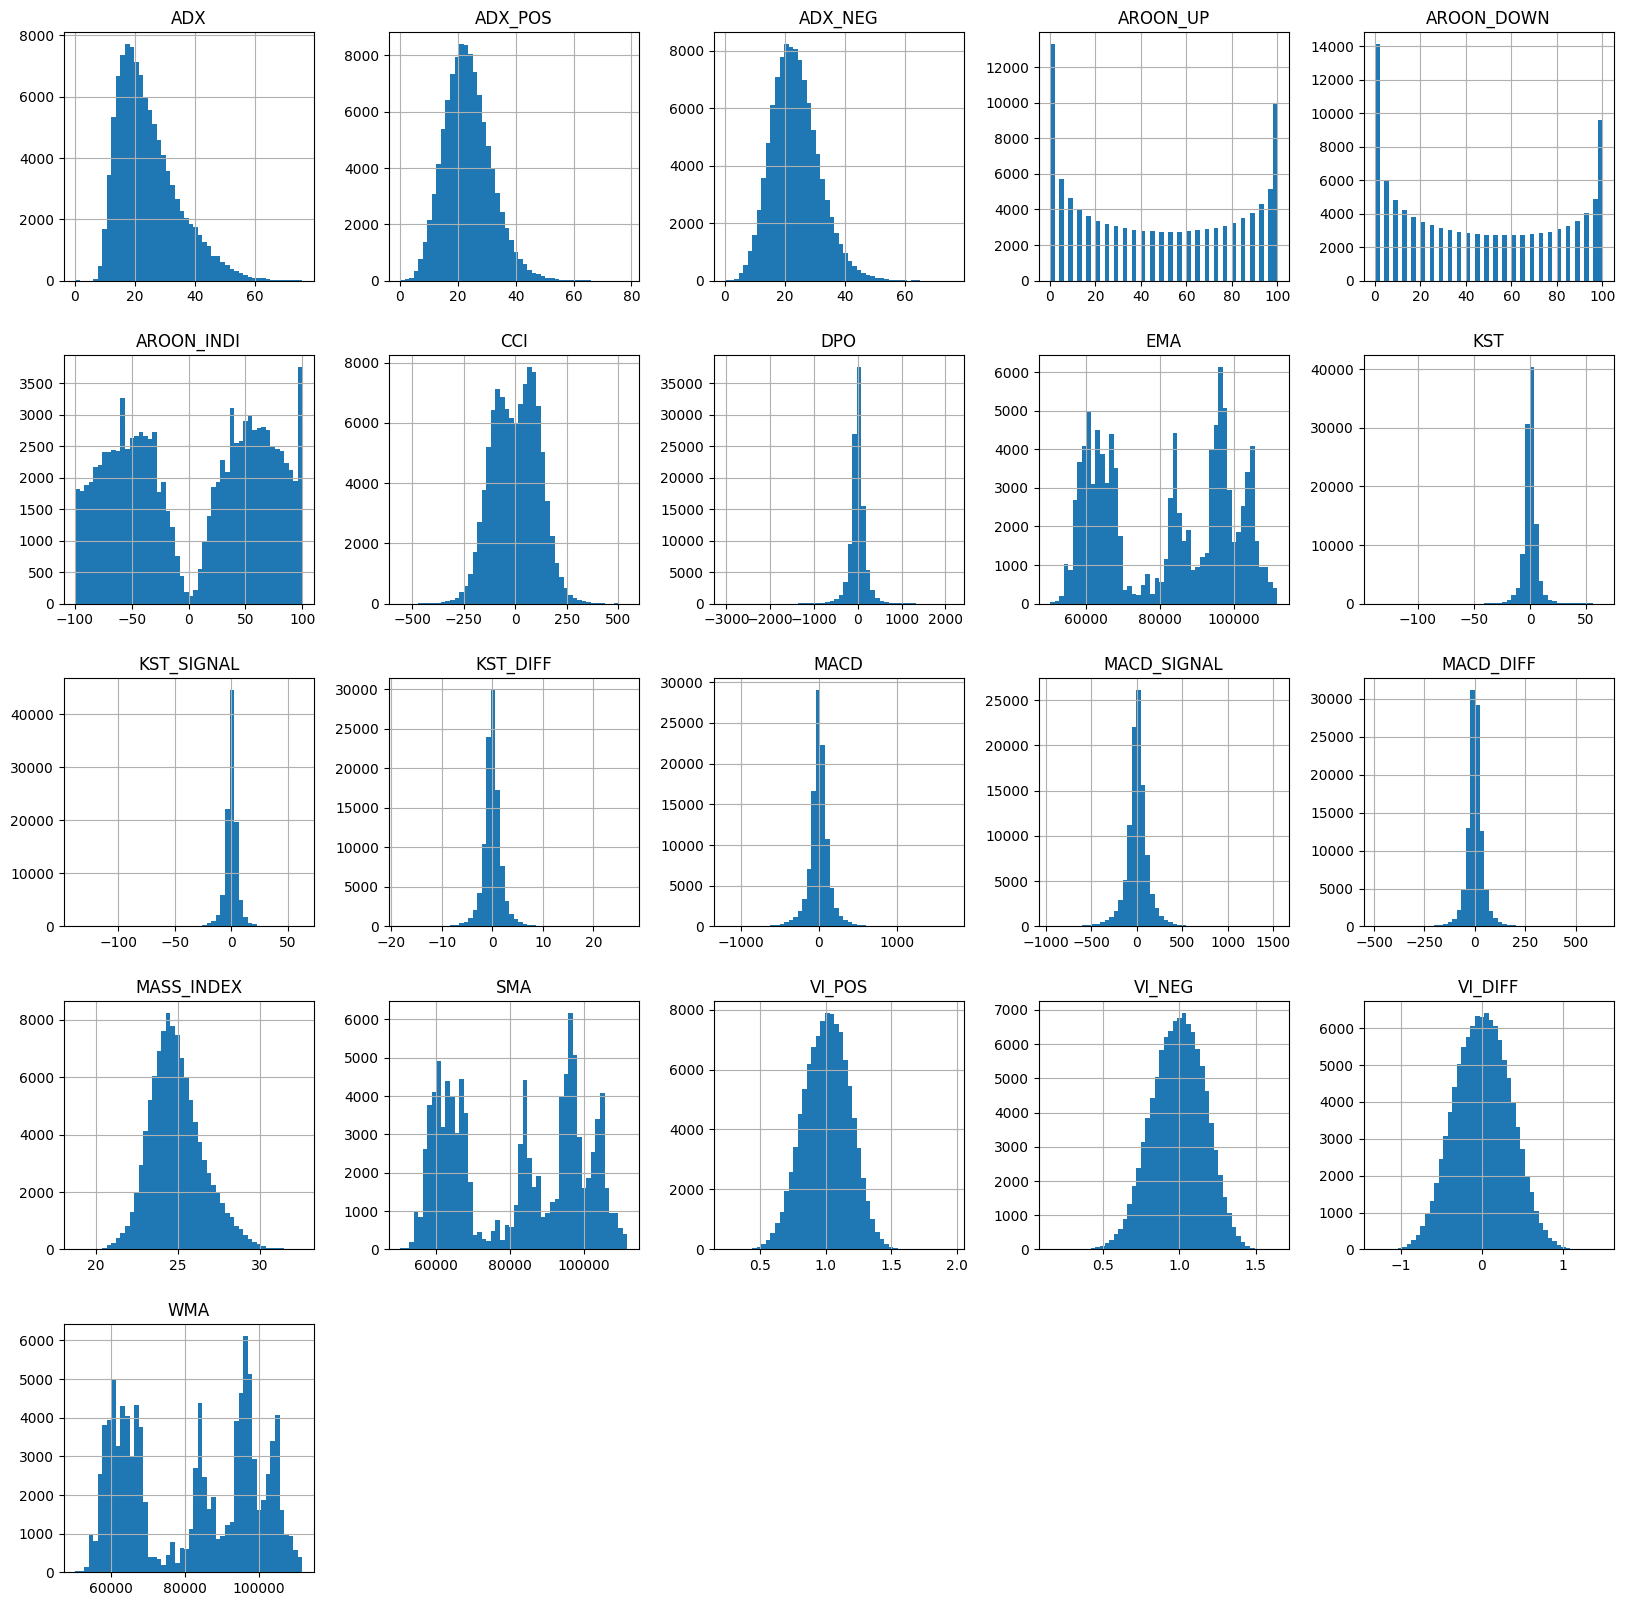

In [199]:
df[TREND].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow">TREND </font>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>VMA</li>
  <li>SMA</li>
  <li>EMA</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated. Also if they have the same porpouse probably im gonna need to chose one and discard the others.</p>

<font color="#5283fe">BELL</font>
<ol>
  <li>ADX</li>
  <li>CCI</li>
  <li>DPO</li>
  <li>KST</li>
  <li>MACD</li>
  <li>MASS</li>
  <li>VI</li>
</ol>
<p>The same as before, need to choose one.</p>

<font color="#5283fe">Aroon</font>
<ol>
  <li>AROON UP</li>
  <li>AROON DOWN</li>
  <li>AROON INDICATOR</li>
</ol>
<p>Need to understand how this works.</p>

# Explore Data

In [200]:
velas = df.copy()

### Look for correlations

##### OCHLV

In [201]:
velas[OCHLV].corr()

,open,close,high,low,volume
open,1.000000,0.999971,0.999983,0.999981,-0.017987
close,0.999971,1.000000,0.999984,0.999983,-0.018062
high,0.999983,0.999984,1.000000,0.999967,-0.014940
low,0.999981,0.999983,0.999967,1.000000,-0.021340
volume,-0.017987,-0.018062,-0.014940,-0.021340,1.000000


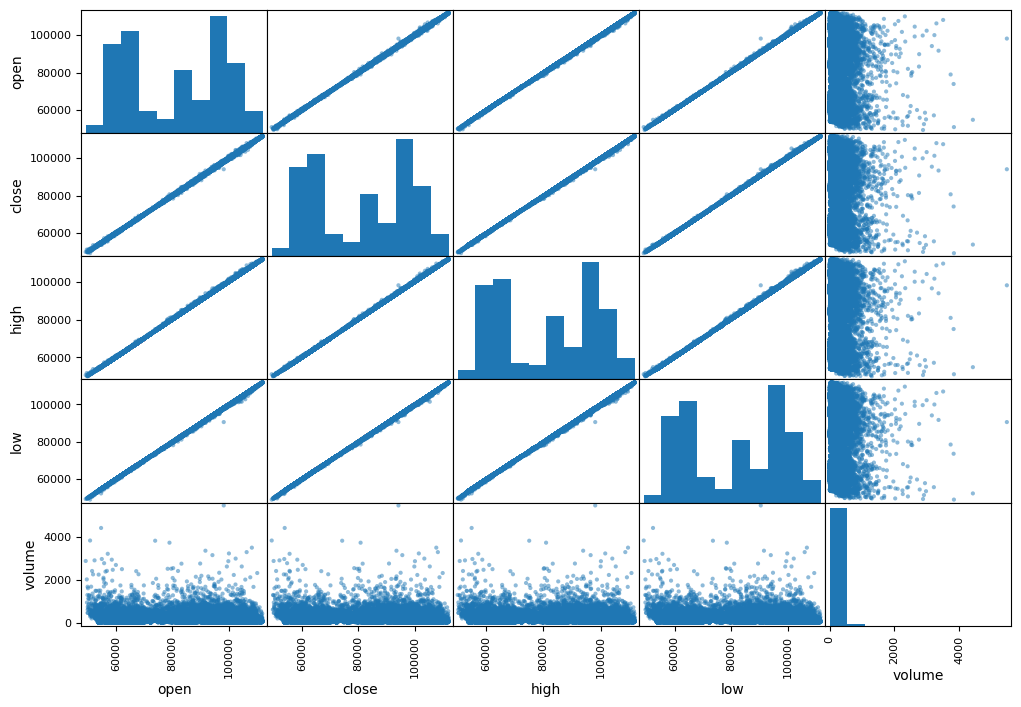

In [202]:
scatter_matrix(velas[OCHLV], figsize=(12, 8))
plt.show()

#### OCHLV with Momentum

In [203]:
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

In [204]:
MOMENTUM_INDIVIDUALS = ["AO", "KAMA", "ROC", "RSI", "TSI"]
MOMENTUM_PPO = ["PPO", "PPO_HIST", "PPO_SIGNAL"]
MOMENTUM_PVO = ["PVO", "PVO_HIST", "PVO_SIGNAL"]
MOMENTUM_STOCH = ["STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL"]

##### Individuals

In [205]:
velas[OCHLV+MOMENTUM_INDIVIDUALS].corr()

,open,close,high,low,volume,AO,KAMA,ROC,RSI,TSI
open,1.000000,0.999971,0.999983,0.999981,-0.017987,0.025685,0.999937,0.013957,0.021653,0.027675
close,0.999971,1.000000,0.999984,0.999983,-0.018062,0.025887,0.999918,0.016053,0.024160,0.028172
high,0.999983,0.999984,1.000000,0.999967,-0.014940,0.025483,0.999928,0.014826,0.022796,0.027735
low,0.999981,0.999983,0.999967,1.000000,-0.021340,0.026289,0.999919,0.015441,0.023323,0.028311
volume,-0.017987,-0.018062,-0.014940,-0.021340,1.000000,-0.053573,-0.017412,-0.053148,-0.032441,-0.032701
AO,0.025685,0.025887,0.025483,0.026289,-0.053573,1.000000,0.019005,0.728080,0.704388,0.831920
KAMA,0.999937,0.999918,0.999928,0.999919,-0.017412,0.019005,1.000000,0.006820,0.014675,0.021733
ROC,0.013957,0.016053,0.014826,0.015441,-0.053148,0.728080,0.006820,1.000000,0.750831,0.622805
RSI,0.021653,0.024160,0.022796,0.023323,-0.032441,0.704388,0.014675,0.750831,1.000000,0.854813
TSI,0.027675,0.028172,0.027735,0.028311,-0.032701,0.831920,0.021733,0.622805,0.854813,1.000000


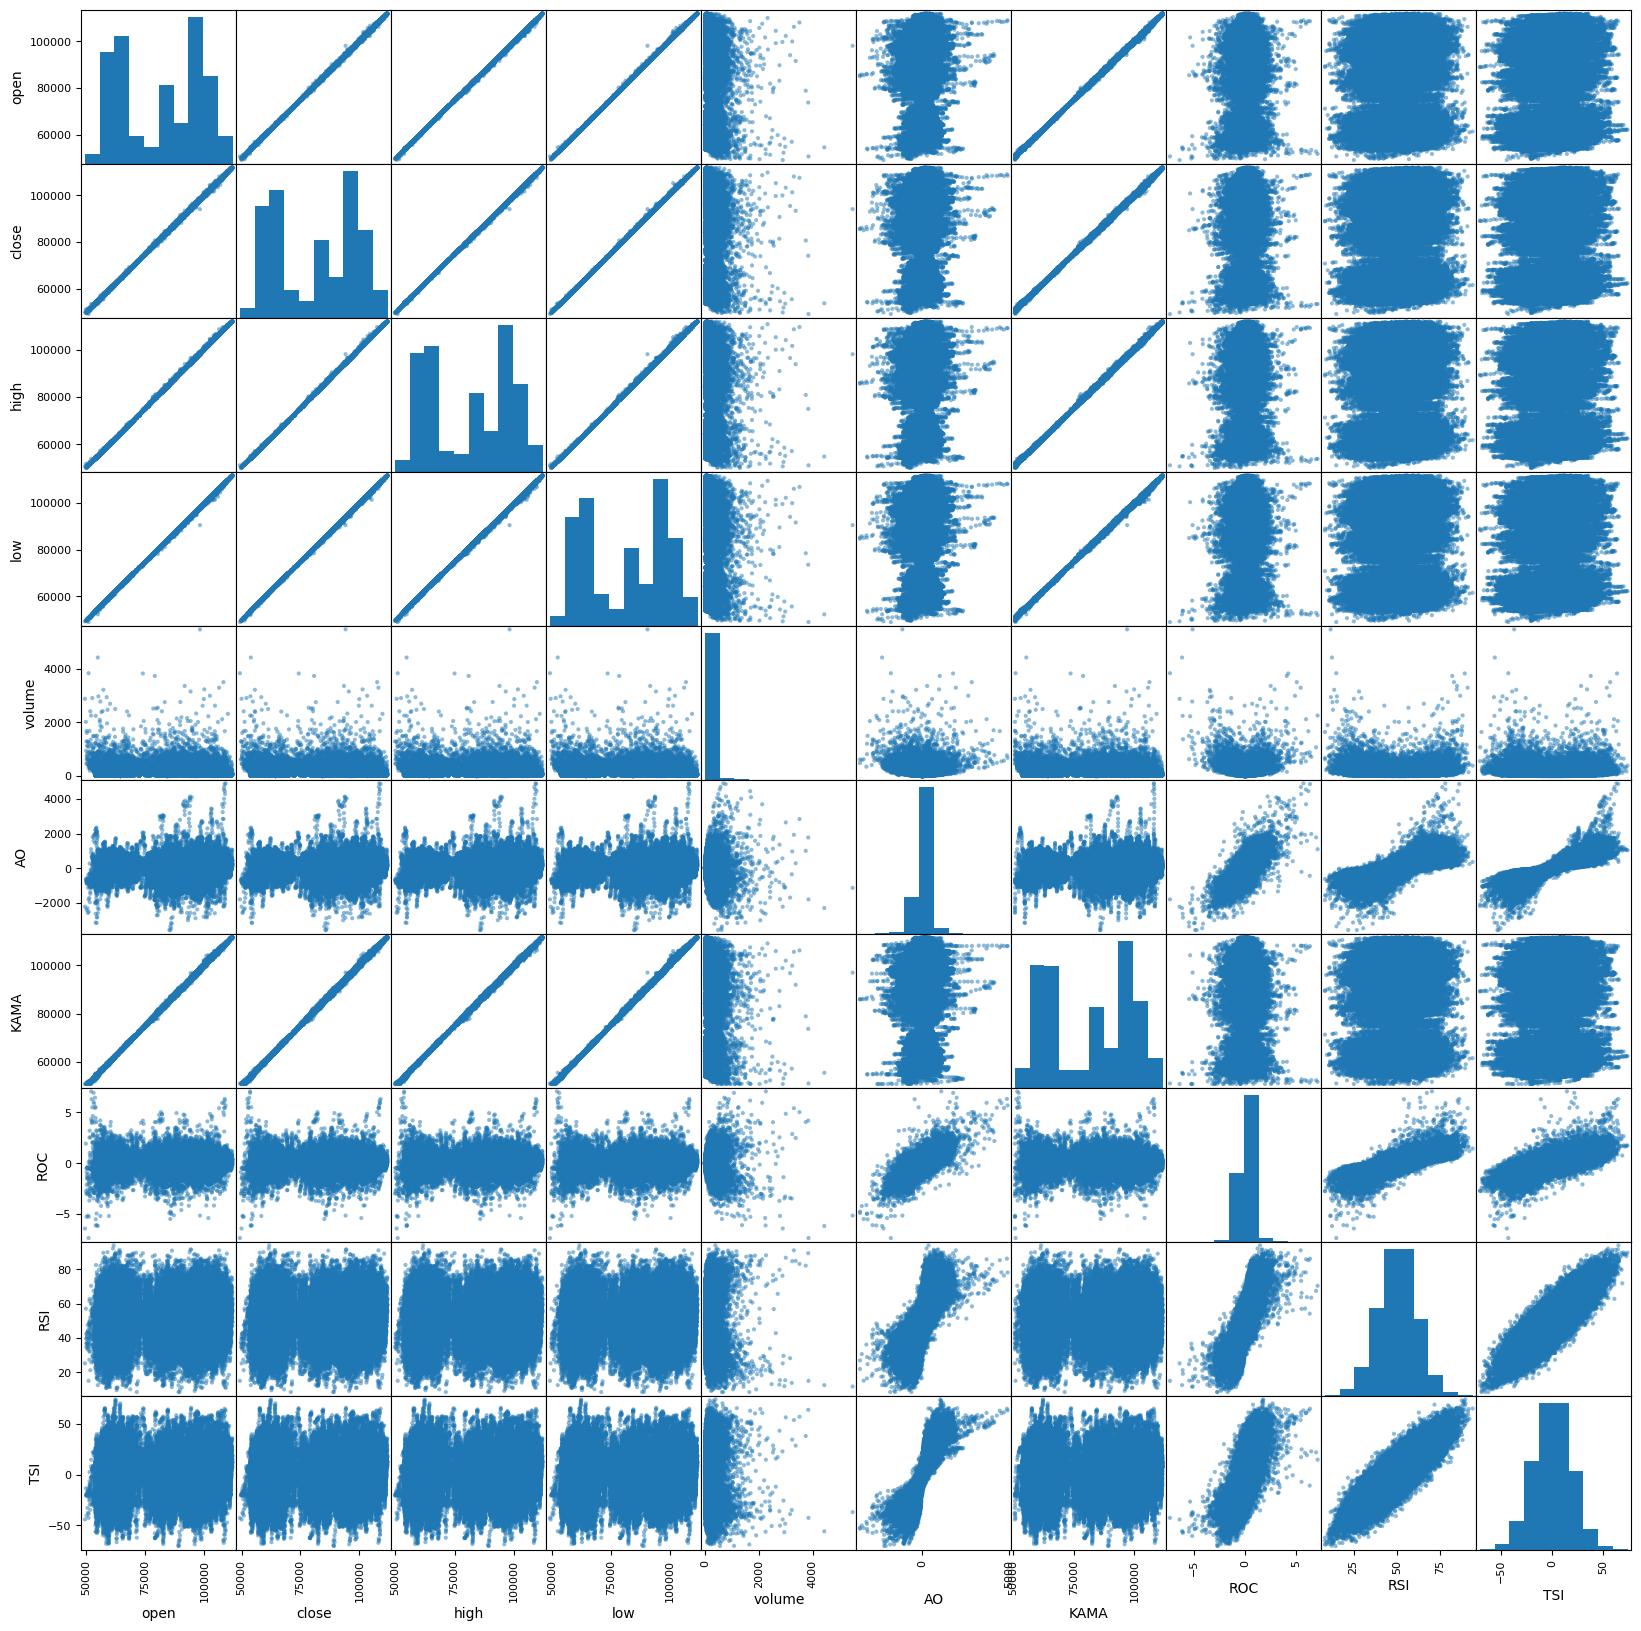

In [206]:
scatter_matrix(velas[OCHLV+MOMENTUM_INDIVIDUALS], figsize=(20, 20))
plt.show()

##### PPO

In [207]:
velas[OCHLV+MOMENTUM_PPO].corr()

,open,close,high,low,volume,PPO,PPO_HIST,PPO_SIGNAL
open,1.000000,0.999971,0.999983,0.999981,-0.017987,0.028567,-0.001206,0.030678
close,0.999971,1.000000,0.999984,0.999983,-0.018062,0.029058,0.000155,0.030767
high,0.999983,0.999984,1.000000,0.999967,-0.014940,0.028470,-0.000614,0.030386
low,0.999981,0.999983,0.999967,1.000000,-0.021340,0.029324,-0.000270,0.031184
volume,-0.017987,-0.018062,-0.014940,-0.021340,1.000000,-0.064154,-0.042022,-0.054755
PPO,0.028567,0.029058,0.028470,0.029324,-0.064154,1.000000,0.336014,0.954427
PPO_HIST,-0.001206,0.000155,-0.000614,-0.000270,-0.042022,0.336014,1.000000,0.039610
PPO_SIGNAL,0.030678,0.030767,0.030386,0.031184,-0.054755,0.954427,0.039610,1.000000


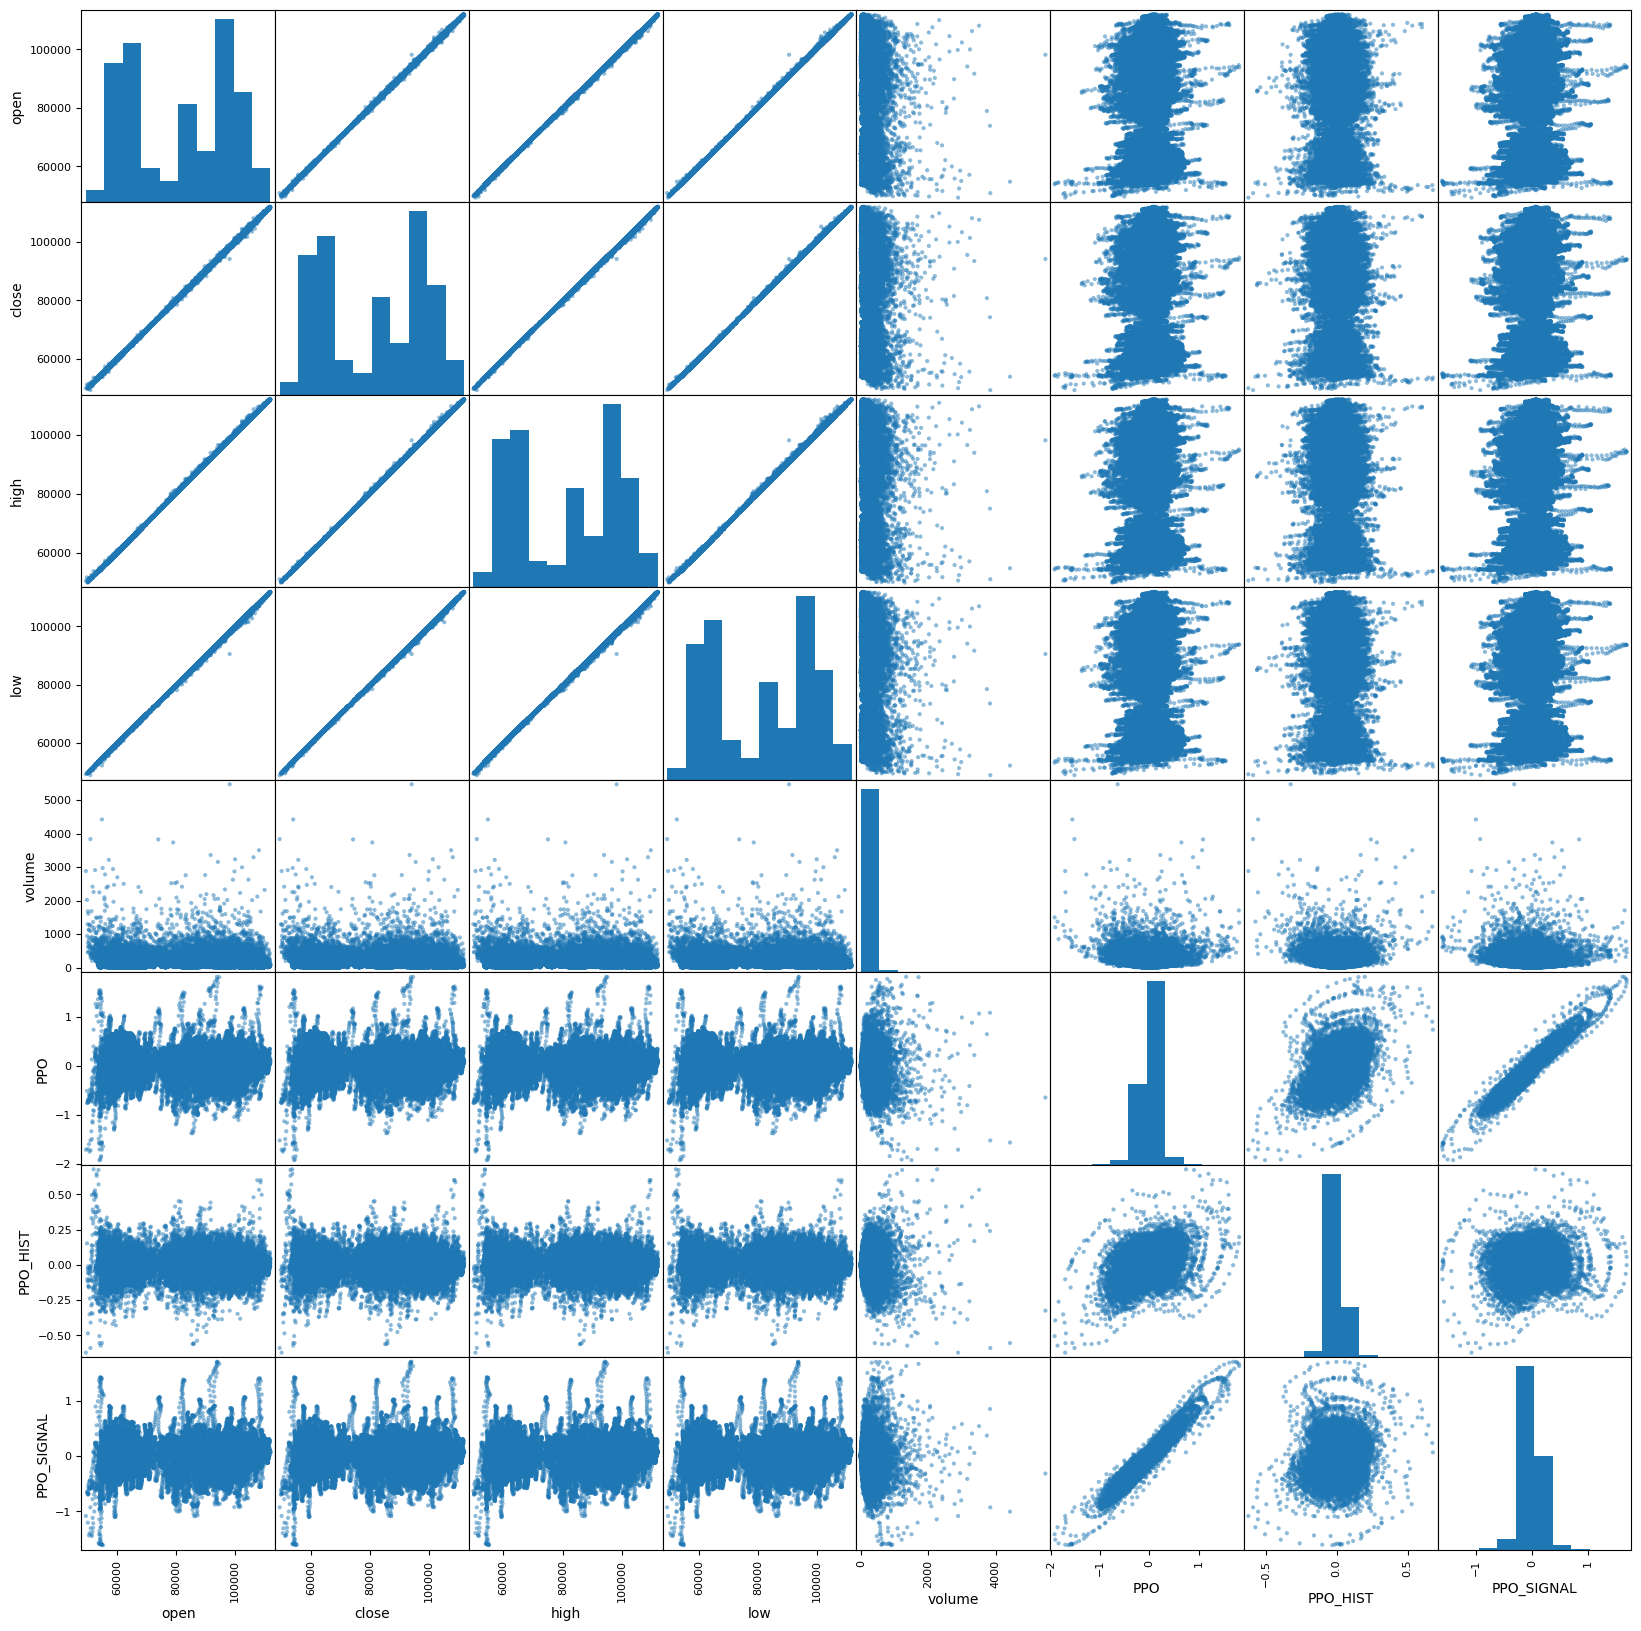

In [208]:
scatter_matrix(velas[OCHLV+MOMENTUM_PPO], figsize=(20, 20))
plt.show()

##### PVO

In [209]:
velas[OCHLV+MOMENTUM_PVO].corr()

,open,close,high,low,volume,PVO,PVO_HIST,PVO_SIGNAL
open,1.000000,0.999971,0.999983,0.999981,-0.017987,0.006631,-0.000250,0.008048
close,0.999971,1.000000,0.999984,0.999983,-0.018062,0.006613,-0.000299,0.008055
high,0.999983,0.999984,1.000000,0.999967,-0.014940,0.008054,0.000784,0.009141
low,0.999981,0.999983,0.999967,1.000000,-0.021340,0.005141,-0.001358,0.006917
volume,-0.017987,-0.018062,-0.014940,-0.021340,1.000000,0.467352,0.369804,0.341327
PVO,0.006631,0.006613,0.008054,0.005141,0.467352,1.000000,0.556805,0.869710
PVO_HIST,-0.000250,-0.000299,0.000784,-0.001358,0.369804,0.556805,1.000000,0.074284
PVO_SIGNAL,0.008048,0.008055,0.009141,0.006917,0.341327,0.869710,0.074284,1.000000


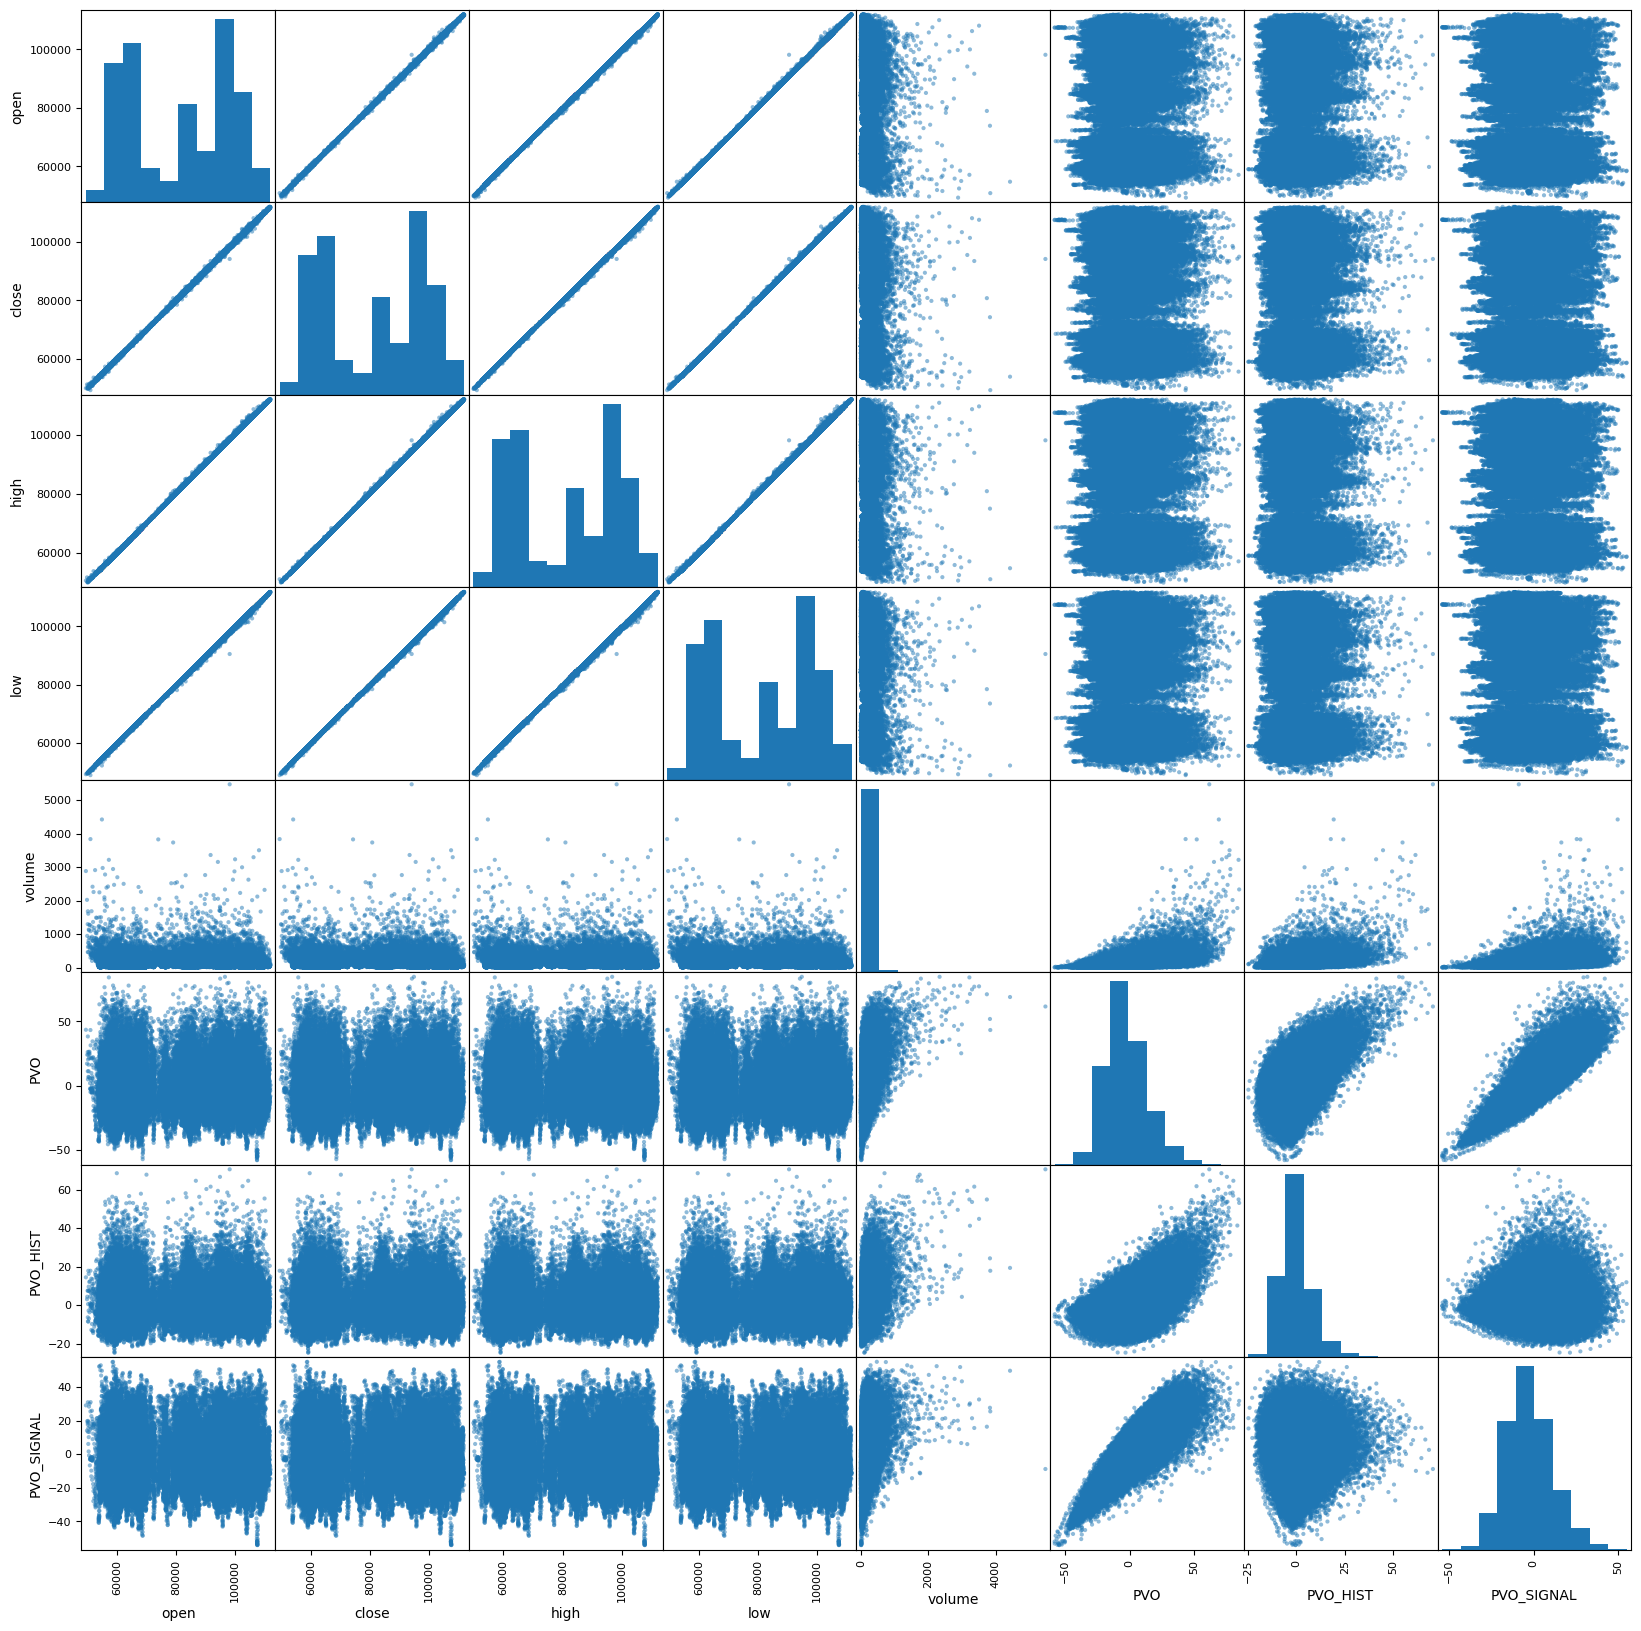

In [210]:
scatter_matrix(velas[OCHLV+MOMENTUM_PVO], figsize=(20, 20))
plt.show()

##### STOCH

In [211]:
velas[OCHLV+MOMENTUM_STOCH].corr()

,open,close,high,low,volume,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
open,1.000000,0.999971,0.999983,0.999981,-0.017987,0.001202,0.014969,0.018279
close,0.999971,1.000000,0.999984,0.999983,-0.018062,0.004393,0.017862,0.019288
high,0.999983,0.999984,1.000000,0.999967,-0.014940,0.002864,0.016294,0.018661
low,0.999981,0.999983,0.999967,1.000000,-0.021340,0.002919,0.016583,0.019001
volume,-0.017987,-0.018062,-0.014940,-0.021340,1.000000,-0.005450,-0.015823,-0.019250
STOCH_RSI,0.001202,0.004393,0.002864,0.002919,-0.005450,1.000000,0.818316,0.662396
STOCH_OSC,0.014969,0.017862,0.016294,0.016583,-0.015823,0.818316,1.000000,0.908112
STOCH_OSC_SIGNAL,0.018279,0.019288,0.018661,0.019001,-0.019250,0.662396,0.908112,1.000000


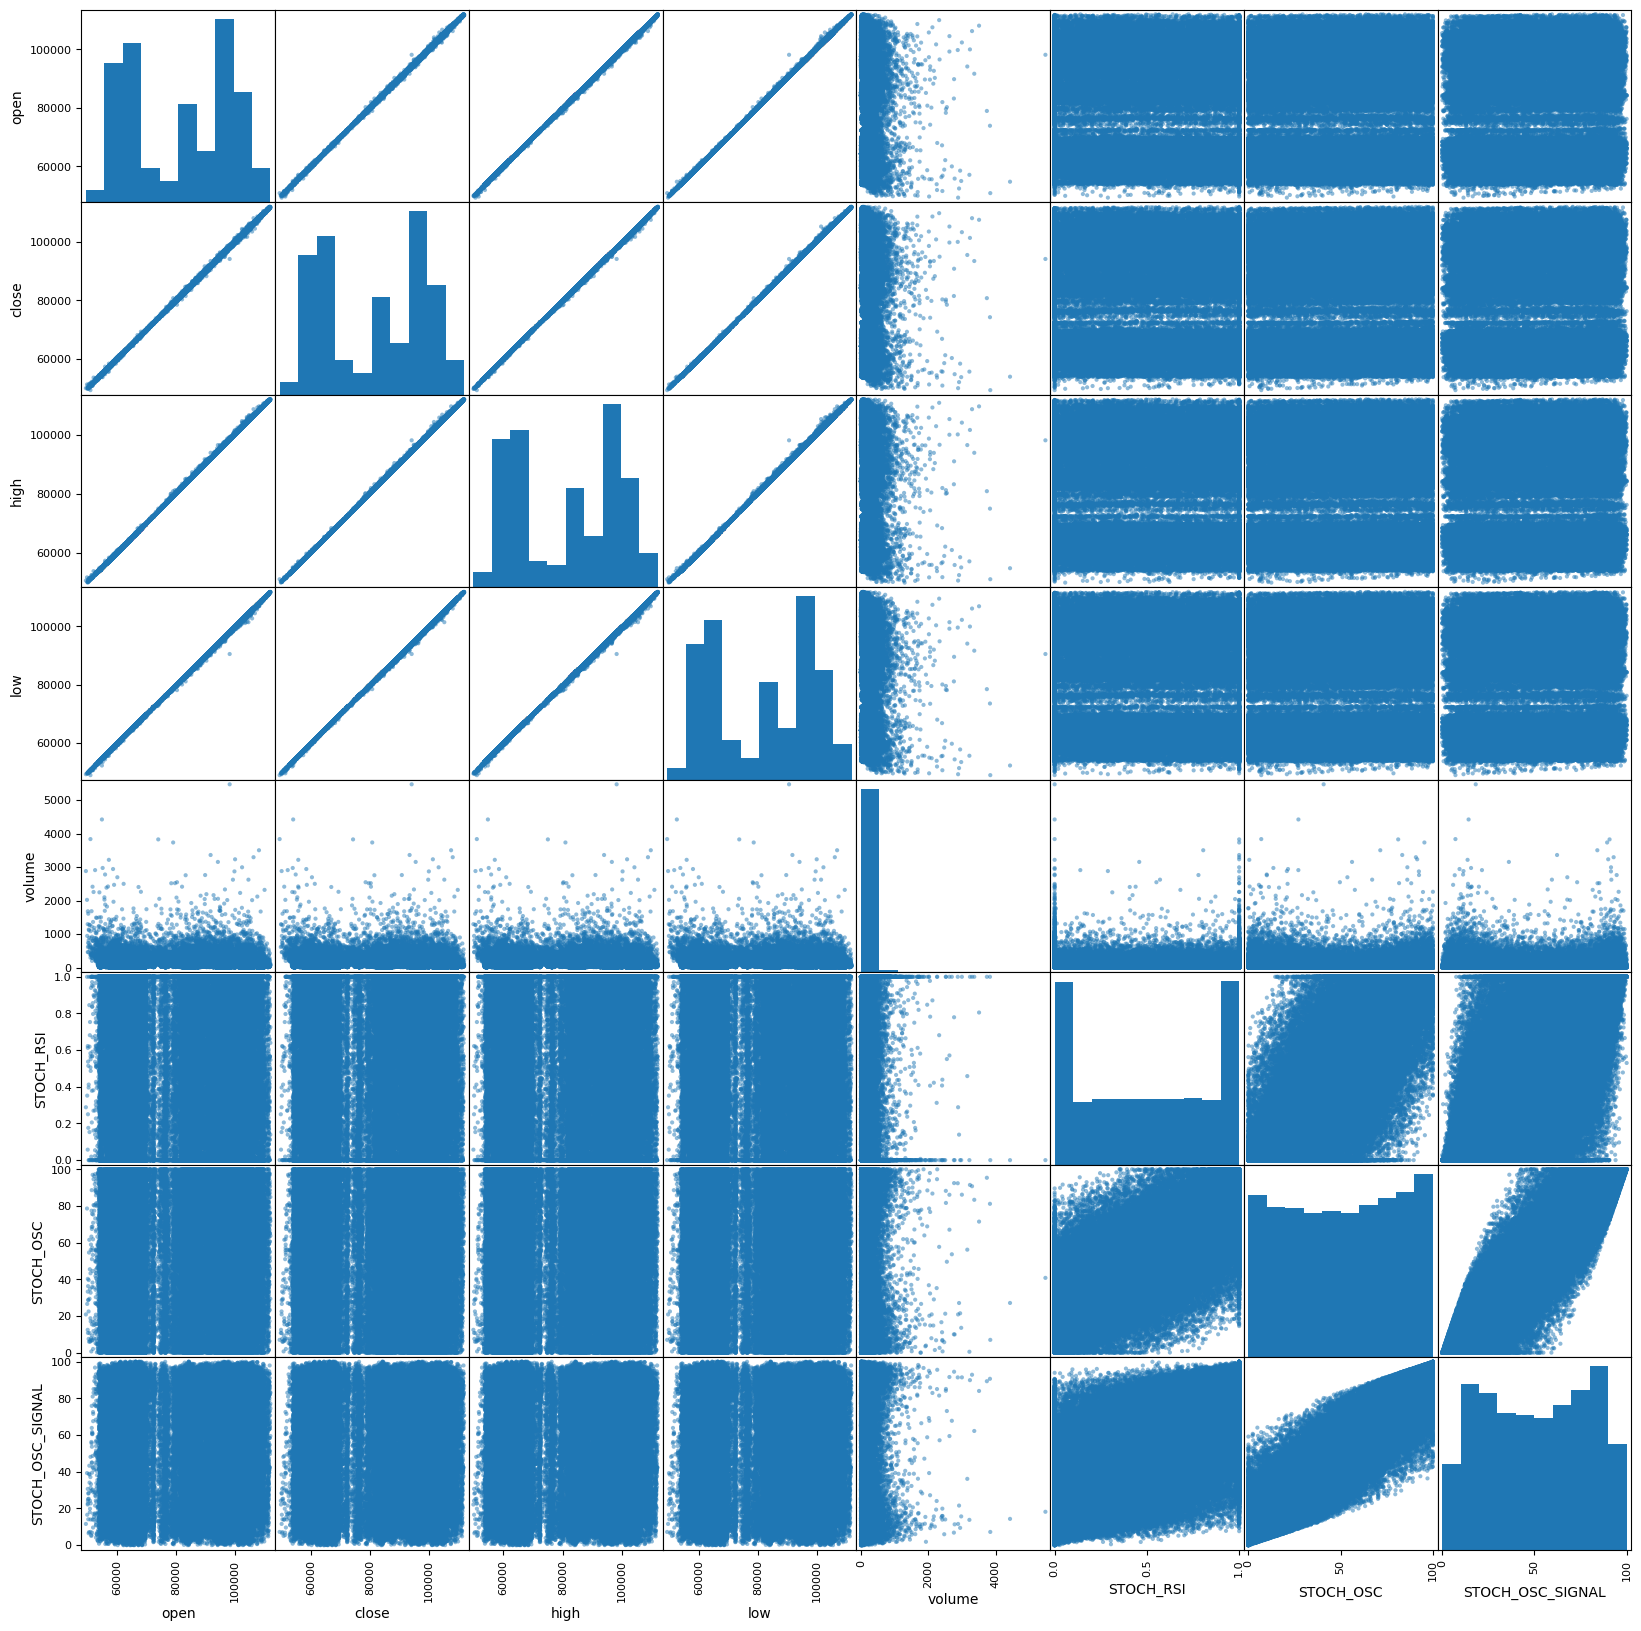

In [212]:
scatter_matrix(velas[OCHLV+MOMENTUM_STOCH], figsize=(20, 20))
plt.show()

##### Only MOMENTUM

In [213]:
velas[MOMENTUM].corr()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
AO,1.000000,0.019005,0.951415,0.443709,0.868758,-0.063849,-0.016201,-0.067028,0.728080,0.704388,0.035869,0.400422,0.501626,0.831920
KAMA,0.019005,1.000000,0.022214,-0.008029,0.026100,0.007267,0.000155,0.008571,0.006820,0.014675,-0.002735,0.008756,0.010826,0.021733
PPO,0.951415,0.022214,1.000000,0.336014,0.954427,-0.057248,-0.008027,-0.063982,0.702993,0.722764,0.010628,0.383768,0.465321,0.861620
PPO_HIST,0.443709,-0.008029,0.336014,1.000000,0.039610,-0.048243,-0.055278,-0.025073,0.823390,0.560650,0.571653,0.627629,0.676930,0.314445
PPO_SIGNAL,0.868758,0.026100,0.954427,0.039610,1.000000,-0.045467,0.009000,-0.059933,0.484899,0.589142,-0.169860,0.208268,0.279166,0.814455
PVO,-0.063849,0.007267,-0.057248,-0.048243,-0.045467,1.000000,0.556805,0.869710,-0.052166,-0.043339,-0.012935,-0.038788,-0.046713,-0.045649
PVO_HIST,-0.016201,0.000155,-0.008027,-0.055278,0.009000,0.556805,1.000000,0.074284,-0.040254,-0.017501,-0.025287,-0.031718,-0.035033,-0.004710
PVO_SIGNAL,-0.067028,0.008571,-0.063982,-0.025073,-0.059933,0.869710,0.074284,1.000000,-0.038729,-0.041687,-0.000470,-0.027741,-0.035303,-0.052006
ROC,0.728080,0.006820,0.702993,0.823390,0.484899,-0.052166,-0.040254,-0.038729,1.000000,0.750831,0.453505,0.658849,0.687638,0.622805
RSI,0.704388,0.014675,0.722764,0.560650,0.589142,-0.043339,-0.017501,-0.041687,0.750831,1.000000,0.508624,0.799310,0.793080,0.854813


###